In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone https://github.com/razorx89/roco-dataset.git

Cloning into 'roco-dataset'...
remote: Enumerating objects: 114, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 114 (delta 7), reused 20 (delta 7), pack-reused 91 (from 1)
Receiving objects: 100% (114/114), 13.01 MiB | 16.14 MiB/s, done.
Resolving deltas: 100% (31/31), done.


# Importing different library

In [2]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import textwrap
import cv2

In [ ]:
!python3 /content/roco-dataset/scripts/fetch.py

Streaming output truncated to the last 5000 lines.
89.300% | 41612/46598 | PMC3984769
89.302% | 41613/46598 | PMC4072392
89.304% | 41614/46598 | PMC3269654
89.306% | 41615/46598 | PMC4621276
89.309% | 41616/46598 | PMC4619577
89.311% | 41617/46598 | PMC1978243
89.313% | 41618/46598 | PMC4432449
89.315% | 41619/46598 | PMC4675004
89.317% | 41620/46598 | PMC3953627
89.319% | 41621/46598 | PMC4460548
89.321% | 41622/46598 | PMC5502573
89.324% | 41623/46598 | PMC4435852
89.326% | 41624/46598 | PMC3290114
89.328% | 41625/46598 | PMC2740835
89.330% | 41626/46598 | PMC2253542
89.332% | 41627/46598 | PMC4055357
89.334% | 41628/46598 | PMC4564506
89.336% | 41629/46598 | PMC3954297
89.339% | 41630/46598 | PMC3015802
89.341% | 41631/46598 | PMC1368977
89.343% | 41632/46598 | PMC4143510
89.345% | 41633/46598 | PMC3627160
89.347% | 41634/46598 | PMC2841377
89.349% | 41635/46598 | PMC4152832
89.351% | 41636/46598 | PMC2629172
89.354% | 41637/46598 | PMC5133587
89.356% | 41638/46598 | PMC3340973
89.3

In [ ]:
import shutil

# Specify the source path in Colab and the destination in Google Drive
source_path = '/content/roco-dataset'
destination_path = '/content/drive/MyDrive/ROCO_dataset/'

# Move the file or folder
shutil.move(source_path, destination_path)


In [ ]:
!zip -r roco.zip /content/drive/MyDrive/ROCO_dataset/

Streaming output truncated to the last 5000 lines.
  adding: content/drive/MyDrive/ROCO_dataset/data/train/radiology/images/ROCO_81067.jpg (deflated 32%)
  adding: content/drive/MyDrive/ROCO_dataset/data/train/radiology/images/ROCO_67681.jpg (deflated 21%)
  adding: content/drive/MyDrive/ROCO_dataset/data/train/radiology/images/ROCO_70866.jpg (deflated 5%)
  adding: content/drive/MyDrive/ROCO_dataset/data/train/radiology/images/ROCO_44718.jpg (deflated 1%)
  adding: content/drive/MyDrive/ROCO_dataset/data/train/radiology/images/ROCO_33577.jpg (deflated 0%)
  adding: content/drive/MyDrive/ROCO_dataset/data/train/radiology/images/ROCO_21846.jpg (deflated 2%)
  adding: content/drive/MyDrive/ROCO_dataset/data/train/radiology/images/ROCO_39641.jpg (deflated 0%)
  adding: content/drive/MyDrive/ROCO_dataset/data/train/radiology/images/ROCO_16055.jpg (deflated 4%)
  adding: content/drive/MyDrive/ROCO_dataset/data/train/radiology/images/ROCO_79431.jpg (deflated 1%)
  adding: content/drive/MyDri

# Load the caption.txt file from non-radiology folder of test folder

In [ ]:
df = pd.read_table('/content/drive/MyDrive/ROCO_dataset/data/test/non-radiology/captions.txt',header=None,names = ['image_id','caption'])

In [ ]:
df

,image_id,caption
0,ROCO_81827,Scanning electron microscopy of demineralized...
1,ROCO_81835,"Schistosomiasis of the liver, showing the pec..."
2,ROCO_81851,Preoperative right fundus and OCT imaging in ...
3,ROCO_81853,Incubation of skin allografts in 85% glycerol...
4,ROCO_81857,“Hans Christian Jacobaeus (1879–1937)” Figure...
...,...,...
607,ROCO_87910,Laryngoscopy Post-treatment.
608,ROCO_87912,Colony and microscopic characteristics of Cam...
609,ROCO_87919,Clinical photograph of CHED demonstrating blu...
610,ROCO_87932,Schematic representation of a brain network m...


No charts were generated by quickchart


Describe the caption column

In [ ]:
df['caption'].describe()

,caption
count,612
unique,612
top,Scanning electron microscopy of demineralized...
freq,1


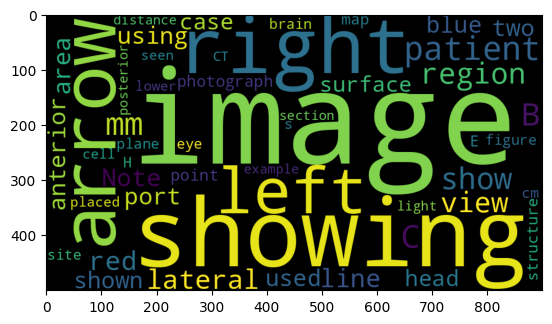

In [ ]:
from wordcloud import WordCloud
caption_text=' '.join(df['caption'].astype(str))
wordcloud=WordCloud(width=900,height=500,max_words=50).generate(caption_text)
plt.imshow(wordcloud)

# Load the dlinks.txt file from non-radiology folder of test folder

In [ ]:
dlink_url='/content/drive/MyDrive/ROCO_dataset/data/test/non-radiology/dlinks.txt'
dlink = pd.read_table(dlink_url,header = None,names=['image_id','dlink','image'])
dlink

,image_id,dlink,image
0,ROCO_81827,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,1678-7757-jaos-14-02-0117-gf05.jpg
1,ROCO_81835,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,0036-4665-rimtsp-56-01-00092-gf01.jpg
2,ROCO_81851,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,opth-9-169Fig1.jpg
3,ROCO_81853,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,10561_2011_9244_Fig1_HTML.jpg
4,ROCO_81857,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,jsls-1-1-83-g02.jpg
...,...,...,...
607,ROCO_87910,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,10-7162-s-1809-97772012000400015-i160415-2.jpg
608,ROCO_87912,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,alm-35-657-g001.jpg
609,ROCO_87919,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,BMRI2015-475392.002.jpg
610,ROCO_87932,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,1471-2202-14-S1-P193-1.jpg


No charts were generated by quickchart


Describe the dlink column

In [ ]:
dlink['dlink'].describe()

,dlink
count,612
unique,601
top,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...
freq,2


Store some image in a list

In [ ]:
img ="/content/drive/MyDrive/ROCO_dataset/data/test/non-radiology/images"#image url
list1 = []
if os.path.exists(img):
    for file in os.listdir(img):
        list1.append(file)
else:
    print(f"The path {img} does not exist.")
len(list1)

610

Captioning some image

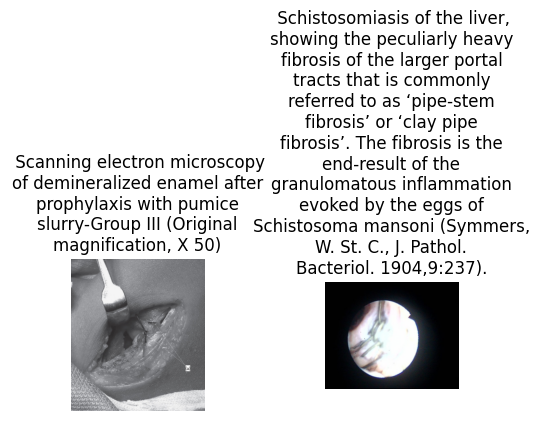

In [ ]:
file_names1 = os.listdir(img)
wrap_width = 30

fig, axs = plt.subplots(1,2, figsize=(5, 6))

plt.subplots_adjust(wspace = 0.9,hspace=0.9)
axs = axs.flatten()
for i in range(2):
    file_path = os.path.join(img, list1[i])
    image = Image.open(file_path)
    caption = df["caption"][i]
    wrapped_caption = "\n".join(textwrap.wrap(caption, wrap_width))
    axs[i].imshow(image)
    axs[i].set_title(wrapped_caption)
    axs[i].axis('off')

plt.show()


creation of dataframe

In [ ]:
# Define the root data directory
data_dir = '/content/drive/MyDrive/ROCO_dataset/data'

# Initialize an empty list to store the data
data = []

# Iterate through each split (train, test, validation)
for split in ['train', 'test', 'validation']:
    split_dir = os.path.join(data_dir, split)

    # Iterate through each category (radiology, non-radiology)
    for category in ['radiology', 'non-radiology']:
        category_dir = os.path.join(split_dir, category)
        captions_file = os.path.join(category_dir, 'captions.txt')

        # Read captions.txt if it exists
        if os.path.exists(captions_file):
            with open(captions_file, 'r') as file:
                # Read each line in the file as a caption
                for line in (file):
                    caption = line[12:].strip()
                    id = line[:12]
                    label = 'radiology' if category == 'radiology' else 'non-radiology'
                    # Append the caption, label, and split type to the data list
                    data.append([id,caption, label, split])

# Create a DataFrame with the collected data
data = pd.DataFrame(data, columns=['image_id','Caption', 'Label', 'Split'])

data


,image_id,Caption,Label,Split
0,ROCO_00002\t,Computed tomography scan in axial view showing...,radiology,train
1,ROCO_00003\t,Bacterial contamination occurred after complet...,radiology,train
2,ROCO_00004\t,The patient had residual paralysis of the hand...,radiology,train
3,ROCO_00005\t,Panoramic radiograph after immediate loading.,radiology,train
4,ROCO_00007\t,Plain abdomen x-ray: Multiple air levels at th...,radiology,train
...,...,...,...,...
87922,ROCO_87894\t,Scanning electron photomicrograph of blood cel...,non-radiology,validation
87923,ROCO_87904\t,SEM of Solenopsis elhawagryi sp. n. minor work...,non-radiology,validation
87924,ROCO_87918\t,Under visualization through the anterolateral ...,non-radiology,validation
87925,ROCO_87936\t,The endoscopic view demonstrated progressive d...,non-radiology,validation


Describe each column of dataframe

In [ ]:
data.describe()

,image_id,Caption,Label,Split
count,87927,87927,87927,87927
unique,87927,86778,2,3
top,ROCO_00002\t,Preoperative radiograph,radiology,train
freq,1,25,81809,70345


Describe caption column of dataframe

In [ ]:
data['Caption'].describe()

,Caption
count,87927
unique,86778
top,Preoperative radiograph
freq,25


In [ ]:
from wordcloud import WordCloud

In [ ]:
caption_text=' '.join(data['Caption'].astype(str))

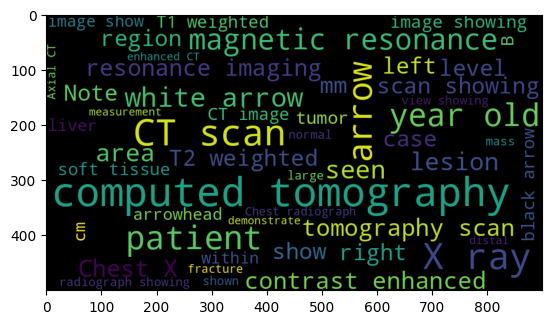

In [ ]:
wordcloud=WordCloud(width=900,height=500,max_words=50).generate(caption_text)
plt.imshow(wordcloud)

Describe split column of dataframe

In [ ]:
data['Split'].describe()

,Split
count,87927
unique,3
top,train
freq,70345


Pie chart of split column for showing distribution of train,test and validation

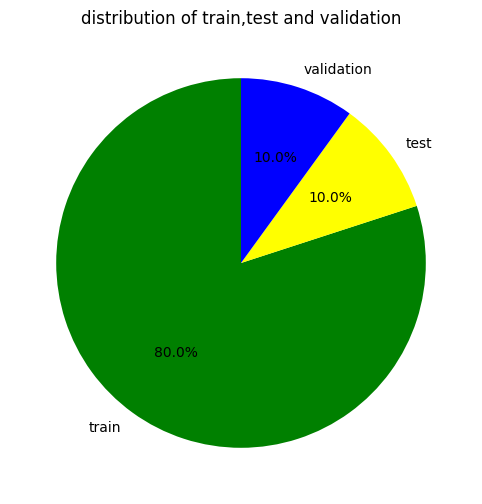

In [ ]:
split_counts = data['Split'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(split_counts, labels=split_counts.index, autopct='%1.1f%%',startangle=90,colors=['green','yellow','blue'])
plt.title('distribution of train,test and validation')
plt.show()

Describe Label column

In [ ]:
data['Label'].describe()

,Label
count,87927
unique,2
top,radiology
freq,81809


Pie chart for showing distribution of radiology and non-radiology

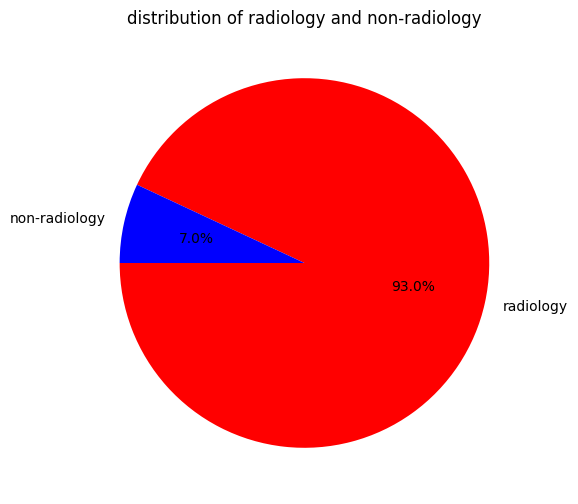

In [ ]:
label_counts = data['Label'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',startangle=180,colors=['red','blue'])
plt.title('distribution of radiology and non-radiology')
plt.show()

## **Image Preprocessing** **technique**

In [ ]:
img_dir = "/content/drive/MyDrive/ROCO_dataset/data/test/radiology/images"

In [ ]:
image_files=[f for f in os.listdir(img_dir) if f.endswith(".jpg")]

In [ ]:
image_files

['ROCO_70136.jpg',
 'ROCO_70088.jpg',
 'ROCO_70141.jpg',
 'ROCO_70242.jpg',
 'ROCO_70236.jpg',
 'ROCO_70158.jpg',
 'ROCO_70192.jpg',
 'ROCO_70256.jpg',
 'ROCO_70244.jpg',
 'ROCO_70276.jpg',
 'ROCO_70266.jpg',
 'ROCO_70286.jpg',
 'ROCO_70278.jpg',
 'ROCO_70297.jpg',
 'ROCO_70288.jpg',
 'ROCO_70347.jpg',
 'ROCO_70296.jpg',
 'ROCO_70317.jpg',
 'ROCO_70381.jpg',
 'ROCO_70349.jpg',
 'ROCO_70370.jpg',
 'ROCO_70355.jpg',
 'ROCO_70398.jpg',
 'ROCO_70393.jpg',
 'ROCO_70412.jpg',
 'ROCO_70445.jpg',
 'ROCO_70436.jpg',
 'ROCO_70434.jpg',
 'ROCO_70423.jpg',
 'ROCO_70458.jpg',
 'ROCO_70473.jpg',
 'ROCO_70488.jpg',
 'ROCO_70478.jpg',
 'ROCO_70527.jpg',
 'ROCO_70521.jpg',
 'ROCO_70560.jpg',
 'ROCO_70565.jpg',
 'ROCO_70536.jpg',
 'ROCO_70593.jpg',
 'ROCO_70622.jpg',
 'ROCO_70610.jpg',
 'ROCO_70602.jpg',
 'ROCO_70618.jpg',
 'ROCO_70651.jpg',
 'ROCO_70629.jpg',
 'ROCO_70643.jpg',
 'ROCO_70733.jpg',
 'ROCO_70663.jpg',
 'ROCO_70665.jpg',
 'ROCO_70741.jpg',
 'ROCO_70771.jpg',
 'ROCO_70787.jpg',
 'ROCO_70837

In [ ]:
img_path=os.path.join(img_dir,image_files[90])

In [ ]:
print(img_path)

/content/drive/MyDrive/ROCO_dataset/data/test/radiology/images/ROCO_71251.jpg


array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       ...,

       [[ 76,  76,  76],
        [122, 122, 122],
        [123, 123, 123],
        ...,
        [112, 112, 112],
        [ 97,  97,  97],
        [ 73,  73,  73]],

       [[ 73,  73,  73],
        [115, 115, 115],
        [121, 121, 121],
        ...,
        [107, 107, 107],
        [ 90,  90,  90],
        [ 64,  64,  64]],

       [[ 72,  72,  72],
        [111, 111, 111],
        [119, 119, 119],
        ...,
        [104, 104, 104],
        [ 87,  87,  87],
        [ 64,  64,  64]]], dtype=uint8)
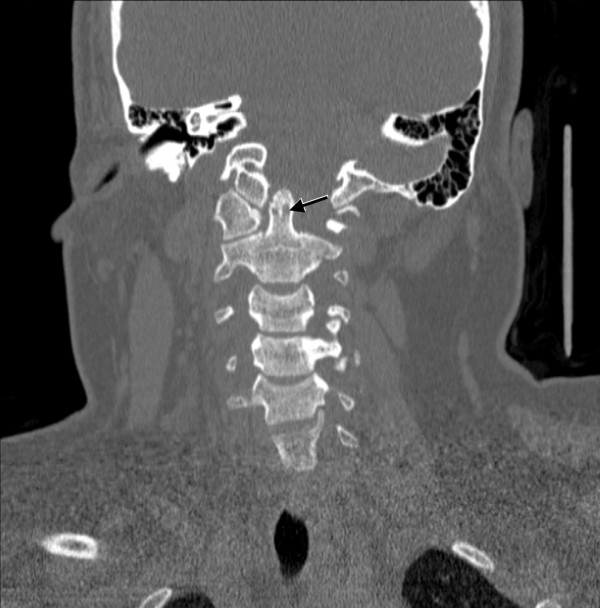

In [ ]:
img=cv2.imread(img_path)
img

In [ ]:
img.shape

(608, 600, 3)

array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       ...,

       [[103, 103, 103],
        [113, 113, 113],
        [103, 103, 103],
        ...,
        [ 66,  66,  66],
        [ 99,  99,  99],
        [ 89,  89,  89]],

       [[118, 118, 118],
        [110, 110, 110],
        [ 93,  93,  93],
        ...,
        [ 88,  88,  88],
        [ 87,  87,  87],
        [ 96,  96,  96]],

       [[106, 106, 106],
        [123, 123, 123],
        [113, 113, 113],
        ...,
        [116, 116, 116],
        [ 85,  85,  85],
        [ 84,  84,  84]]], dtype=uint8)
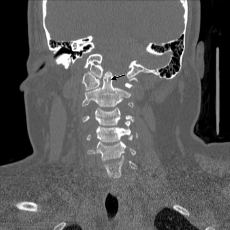

In [ ]:
target_size=(230,230)
cv2.resize(img,target_size)

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [ 76, 122, 123, ..., 112,  97,  73],
       [ 73, 115, 121, ..., 107,  90,  64],
       [ 72, 111, 119, ..., 104,  87,  64]], dtype=uint8)
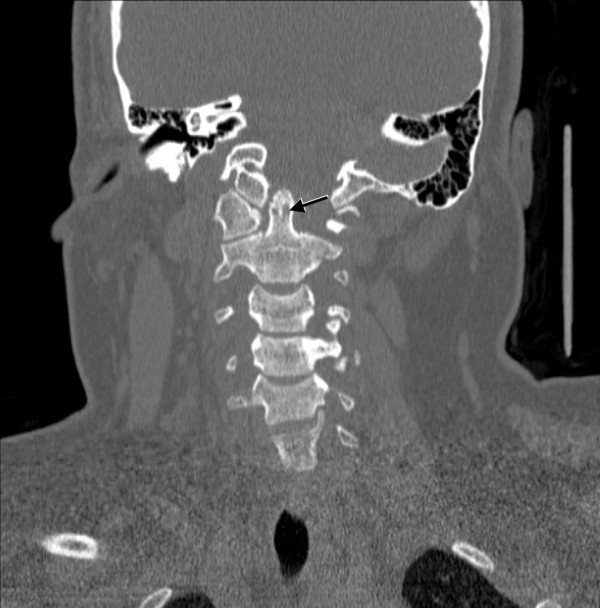

In [ ]:
img_processed=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
img_processed

In [ ]:
img_normalised=img/255
img_normalised

array([[[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       [[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       [[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       ...,

       [[0.29803922, 0.29803922, 0.29803922],
        [0.47843137, 0.47843137, 0.47843137],
        [0.48235294, 0

In [ ]:
# Optional: Apply histogram equalization and denoising
img_eq = cv2.equalizeHist(img_processed.squeeze())
print(f"Equalized Image (first 5 pixels): {img_eq[:5, :5]}")

img_denoised = cv2.GaussianBlur(img_eq, (5, 5), 0)
print(f"Denoised Image (first 5 pixels): {img_denoised[:5, :5]}")

Equalized Image (first 5 pixels): [[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Denoised Image (first 5 pixels): [[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


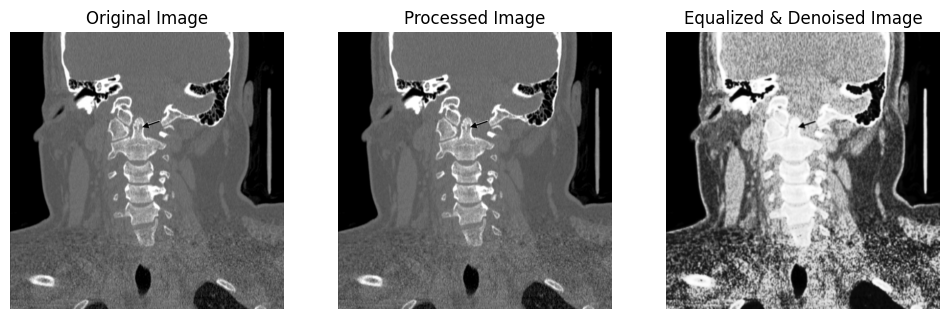

In [ ]:
# Visualize the original, preprocessed, and denoised images

plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 3, 1)
img_original = cv2.imread(img_path)
plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Processed Image (Grayscale & Normalized)
plt.subplot(1, 3, 2)
plt.imshow(img_processed.squeeze(), cmap='gray')
plt.title('Processed Image')
plt.axis('off')

# Equalized and Denoised Image (Optional)
plt.subplot(1, 3, 3)
plt.imshow(img_denoised, cmap='gray')
plt.title('Equalized & Denoised Image')
plt.axis('off')

plt.show()


In [ ]:
import tensorflow as tf

In [ ]:
img=np.expand_dims(img,axis=0)


In [ ]:
datagen=tf.keras.preprocessing.image.ImageDataGenerator(
    #rotation_range=40,
    #width_shift_range=0.2,
    #height_shift_range=0.2
    #zoom_range=0.2,
    horizontal_flip=0.2
                                        )
it=datagen.flow(img,batch_size=1)
augmented_images=[next(it)[0] for _ in range(5)]

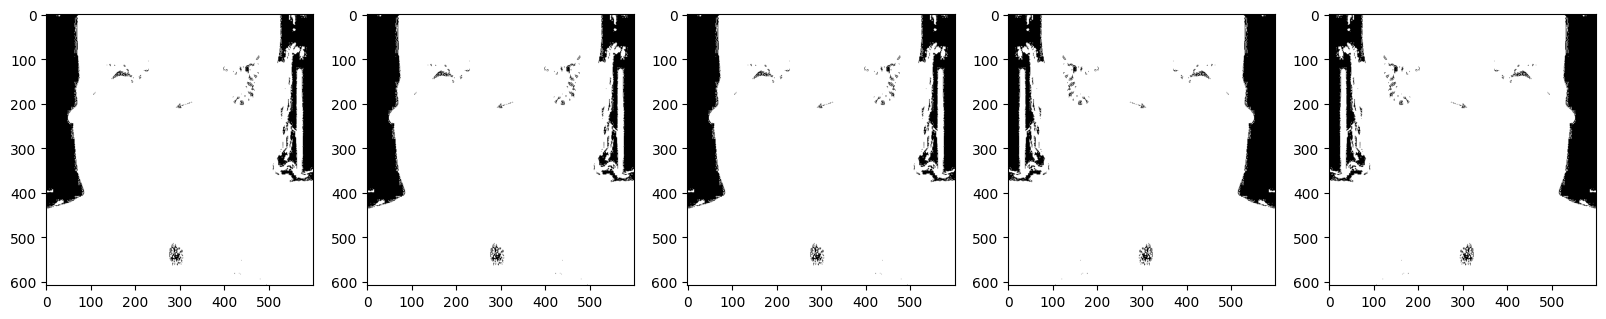

In [ ]:
plt.figure(figsize=(20,5))
for i,aug_img in enumerate(augmented_images):
  plt.subplot(1,5,i+1)
  plt.imshow(aug_img)

NLP Preprocessing Techniques

In [ ]:
corpus = "A corpus can be defined as a collection of text documents. It can be thought as just a bunch of text files in a directory, often alongside many other directories of text files."

In [ ]:
corpus = corpus.lower()

In [ ]:
print(corpus)

a corpus can be defined as a collection of text documents. it can be thought as just a bunch of text files in a directory, often alongside many other directories of text files.


In [ ]:
cap_txt= pd.read_table('/content/drive/MyDrive/ROCO_dataset/data/test/non-radiology/captions.txt',header=None,names = ['image_id','caption'])

In [ ]:
cap_txt

,image_id,caption
0,ROCO_81827,Scanning electron microscopy of demineralized...
1,ROCO_81835,"Schistosomiasis of the liver, showing the pec..."
2,ROCO_81851,Preoperative right fundus and OCT imaging in ...
3,ROCO_81853,Incubation of skin allografts in 85% glycerol...
4,ROCO_81857,“Hans Christian Jacobaeus (1879–1937)” Figure...
...,...,...
607,ROCO_87910,Laryngoscopy Post-treatment.
608,ROCO_87912,Colony and microscopic characteristics of Cam...
609,ROCO_87919,Clinical photograph of CHED demonstrating blu...
610,ROCO_87932,Schematic representation of a brain network m...


In [ ]:
cap_txt['caption']=cap_txt['caption'].str.lower()

In [ ]:
cap_txt['caption'][602]

' three-dimensional image displays the circumferential bone defect from the palatal aspect (red arrows)'

stop words

In [ ]:
from nltk.corpus import stopwords

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stop_words=set(stopwords.words('english'))

In [ ]:
print(stop_words)

{'she', 'down', 'yourselves', 'about', 'just', 'hasn', 'being', 'its', 'them', 'have', 'by', 'how', 'because', 've', 'can', 'these', 'needn', 'him', 'a', 'between', 'below', "wasn't", 'ours', 'not', 'should', 'only', "mustn't", 'myself', 'very', 'will', 'than', 'mightn', "wouldn't", 'when', "mightn't", 'under', 'other', 'which', 'to', 'each', 'further', 'against', 'your', 'is', 'her', 'in', 'at', 'on', 'once', 'and', 'are', 'own', 'now', 'before', "didn't", "you'll", "isn't", 'if', "that'll", 'some', 'ma', 'you', 'he', 'during', 'why', 'while', 'hers', 'what', 'was', 'for', 'or', 'too', "doesn't", "shouldn't", 'this', 'off', 'until', 'who', "you're", 'his', 'hadn', 'd', 'an', 'do', 'theirs', "needn't", 'were', 'doesn', 'that', 'wouldn', 'yours', 'weren', "won't", 'we', 'itself', "shan't", 'herself', 'of', 'they', 'the', 'wasn', 'over', 'ourselves', 'above', 'ain', 'themselves', 'through', 'no', 'more', "you'd", 'after', 'couldn', 'up', 'all', 'haven', 'there', "don't", "hadn't", 'yours

In [ ]:
len(cap_txt)

612

In [ ]:
for i in range(len(cap_txt)):
  corpus=cap_txt['caption'][i]
  text_input=" ".join([word for word in corpus.split() if word not in stop_words])
  cap_txt.loc[i, "caption"] = text_input
  #cap_txt['caption'][i]=text_input

In [ ]:
cap_txt

,image_id,caption
0,ROCO_81827,scanning electron microscopy demineralized ena...
1,ROCO_81835,"schistosomiasis liver, showing peculiarly heav..."
2,ROCO_81851,preoperative right fundus oct imaging case 1.n...
3,ROCO_81853,incubation skin allografts 85% glycerol 36°c
4,ROCO_81857,“hans christian jacobaeus (1879–1937)” figure ...
...,...,...
607,ROCO_87910,laryngoscopy post-treatment.
608,ROCO_87912,colony microscopic characteristics campylobact...
609,ROCO_87919,clinical photograph ched demonstrating bluish-...
610,ROCO_87932,schematic representation brain network model t...


In [ ]:
print(cap_txt['caption'][603])

robot-assisted nephroureterectomy without patient's repositioning, using hybrid port. 12-mm camera port (■) placed superior umbilical region two 8-mm robotic ports (●) placed lateral rectus margin (first), 3–4 cm umbilicus midline umbilicus xiphoid process (second). dual 8–12-mm assistant hybrid port (◙) placed umbilicus pubic symphysis, allows intubated 8-mm robotic arm. robotic nephrectomy completed, robotic axis switched distal ureterectomy configuration robotic ports changed. thus, port first robotic instrument arm nephrectomy becomes assistant port bladder cuff excision, port second robotic instrument arm becomes dominant hand assistant port converted nondominant hand


In [ ]:
from textblob import TextBlob

In [ ]:
TextBlob(cap_txt['caption'][10]).correct()

TextBlob("cast sample depicting rugay shapes marked follows: purification (red), annular (green), wavy (blue), curved (arrow), straight (charon)")

Tokenization

```
`# This is formatted as code`
```



In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
from nltk.tokenize import sent_tokenize

In [ ]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
sent_tokenize(cap_txt['caption'][0])

['scanning electron microscopy demineralized enamel prophylaxis pumice slurry-group iii (original magnification, x 50)']

In [ ]:
from nltk.tokenize import wordpunct_tokenize

In [ ]:
wordpunct_tokenize(cap_txt['caption'][0])

['scanning',
 'electron',
 'microscopy',
 'demineralized',
 'enamel',
 'prophylaxis',
 'pumice',
 'slurry',
 '-',
 'group',
 'iii',
 '(',
 'original',
 'magnification',
 ',',
 'x',
 '50',
 ')']

In [ ]:
from nltk.tokenize import TreebankWordTokenizer
tokenizer = TreebankWordTokenizer()
tokenizer.tokenize(cap_txt['caption'][0])

['scanning',
 'electron',
 'microscopy',
 'demineralized',
 'enamel',
 'prophylaxis',
 'pumice',
 'slurry-group',
 'iii',
 '(',
 'original',
 'magnification',
 ',',
 'x',
 '50',
 ')']

# Stemming

In [ ]:
words=['eating','eats','eaten','writing','writes','programming']

In [ ]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()

In [ ]:
for word in words:
  print(word,"......"+ps.stem(word))

eating ......eat
eats ......eat
eaten ......eaten
writing ......write
writes ......write
programming ......program


In [ ]:
ps.stem("congratulations")

'congratul'

In [ ]:
df1=pd.read_table("/content/drive/MyDrive/ROCO_dataset/data/test/non-radiology/keywords.txt",header=None,names=['image_id','col1','reason','body_part','element','disease','col2','col3','col4','col5','col6'],sep="\t",on_bad_lines='skip')

In [ ]:
df1

,image_id,col1,reason,body_part,element,disease,col2,col3,col4,col5,col6
0,ROCO_81827,NaN,demineralized,slurrygroup,enamel,pumouse,prophylaxi,electron,microscopy,magnification,original
1,ROCO_81853,NaN,incubation,skin,glycerol,allograft,NaN,NaN,NaN,NaN,NaN
2,ROCO_81857,NaN,jacobaeu,highlight,christian,han,figure,NaN,NaN,NaN,NaN
3,ROCO_81867,NaN,extension,colonoscopy,biopsy,tumor,adenocarcinoma,circumferential,rectosigmoid,type,NaN
4,ROCO_81884,NaN,photograph,right,superolateral,suprapatellar,aspiration,bursa,knee,injection,approach
...,...,...,...,...,...,...,...,...,...,...,...
356,ROCO_87876,NaN,aspect,palatal,image,arrow,defect,threedimensional,red,circumferential,bone
357,ROCO_87885,NaN,right,eye,valved,view,cadaver,intraoperative,rabbit,cannula,left
358,ROCO_87900,NaN,pelvi,purulent,drainage,NaN,NaN,NaN,NaN,NaN,NaN
359,ROCO_87903,NaN,canal,right,scan,pet,region,inguinal,anal,uptake,NaN


In [ ]:
list1=[]
for i in df1['reason']:
  list1.append(i)
list1

['demineralized',
 'incubation',
 'jacobaeu',
 'extension',
 'photograph',
 'point',
 'case',
 'dentin',
 'ball',
 'rupture',
 'oocyte',
 'asymmetric',
 'impression',
 'image',
 'vr',
 'cystoid',
 'implantation',
 'surgery',
 'bulb',
 'wound',
 'mas',
 'pigmentation',
 'comparison',
 'opacity',
 'anglia',
 'achille',
 'speciman',
 'map',
 'scrotal',
 'clip',
 'torsion',
 'device',
 'lateral',
 'basal',
 'body',
 'body',
 'case',
 'fistula',
 'ix',
 'occipitocervical',
 'plant',
 'protuberance',
 'reference',
 'prototype',
 'limb',
 'repair',
 'end',
 'trocar',
 'university',
 'diagram',
 'inflammatory',
 'iwqi',
 'transnasal',
 'image',
 'week',
 'upper',
 'ball',
 'case',
 'pattern',
 'len',
 'appliance',
 'superior',
 'bougie',
 'positioning',
 'stone',
 'urinary',
 'technique',
 'terminal',
 'body',
 'wire',
 'patient',
 'wheel',
 'dodziuk',
 'thoracotomy',
 'echocardiography',
 'hnf4dna',
 'barbicide',
 'pattern',
 'embedded',
 'view',
 'placement',
 'extremity',
 'position',
 'tap

In [ ]:
for i in list1:
  print(i,"......"+ps.stem(i))

demineralized ......deminer
incubation ......incub
jacobaeu ......jacobaeu
extension ......extens
photograph ......photograph
point ......point
case ......case
dentin ......dentin
ball ......ball
rupture ......ruptur
oocyte ......oocyt
asymmetric ......asymmetr
impression ......impress
image ......imag
vr ......vr
cystoid ......cystoid
implantation ......implant
surgery ......surgeri
bulb ......bulb
wound ......wound
mas ......ma
pigmentation ......pigment
comparison ......comparison
opacity ......opac
anglia ......anglia
achille ......achil
speciman ......speciman
map ......map
scrotal ......scrotal
clip ......clip
torsion ......torsion
device ......devic
lateral ......later
basal ......basal
body ......bodi
body ......bodi
case ......case
fistula ......fistula
ix ......ix
occipitocervical ......occipitocerv
plant ......plant
protuberance ......protuber
reference ......refer
prototype ......prototyp
limb ......limb
repair ......repair
end ......end
trocar ......trocar
university .....

# RegexpStemmer

In [ ]:
from nltk.stem import RegexpStemmer

In [ ]:
reg_stemer=RegexpStemmer('ing$|e$|s$|able$')

In [ ]:
reg_stemer.stem("eating")

'eat'

In [ ]:
reg_stemer.stem("trains")

'train'

In [ ]:
reg_stemer.stem("ingeating")

'ingeat'

In [ ]:
list2=[]
for i in df1['body_part']:
    list2.append(i)

In [ ]:
list2

['slurrygroup',
 'skin',
 'highlight',
 'colonoscopy',
 'right',
 'vertebral',
 'absces',
 'desired',
 'milling',
 'descemet',
 'adherent',
 'nipple',
 'rvg',
 'wire',
 'willi',
 'patient',
 'lag',
 'mass',
 'olfactory',
 'suture',
 'vulvar',
 'sclerodermatou',
 'mm',
 'verticillata',
 'zuckerman',
 'giovanni',
 'swab',
 'probability',
 'perineal',
 'site',
 'gallbladder',
 'milling',
 'retinaculum',
 'model',
 'mandibular',
 'study',
 'urethroscopic',
 'female',
 'squamou',
 'median',
 'host',
 'face',
 'imu',
 'pump',
 'presentation',
 'organ',
 'nasotracheal',
 'gastrectomy',
 'sigeristcourtesy',
 'ear',
 'multiple',
 'main',
 'catheter',
 nan,
 'undisturbed',
 'scan',
 'aerobic',
 'index',
 'image',
 'week',
 'thurow',
 'laryngeal',
 'indigenou',
 'patient',
 'arrow',
 'zephyr',
 'scheme',
 'tlc',
 'residual',
 'lateral',
 'scan',
 'camber',
 'structure',
 'cannula',
 'threedimensional',
 'crystal',
 nan,
 'haz',
 'needleknife',
 'macroscopic',
 'occlusion',
 'lower',
 'image',
 'm

In [ ]:
for i in list2:
  print(i,"........",reg_stemer.stem(str(i)))

slurrygroup ........ slurrygroup
skin ........ skin
highlight ........ highlight
colonoscopy ........ colonoscopy
right ........ right
vertebral ........ vertebral
absces ........ absce
desired ........ desired
milling ........ mill
descemet ........ descemet
adherent ........ adherent
nipple ........ nippl
rvg ........ rvg
wire ........ wir
willi ........ willi
patient ........ patient
lag ........ lag
mass ........ mas
olfactory ........ olfactory
suture ........ sutur
vulvar ........ vulvar
sclerodermatou ........ sclerodermatou
mm ........ mm
verticillata ........ verticillata
zuckerman ........ zuckerman
giovanni ........ giovanni
swab ........ swab
probability ........ probability
perineal ........ perineal
site ........ sit
gallbladder ........ gallbladder
milling ........ mill
retinaculum ........ retinaculum
model ........ model
mandibular ........ mandibular
study ........ study
urethroscopic ........ urethroscopic
female ........ femal
squamou ........ squamou
median .......

In [ ]:
##SnowBallStemmer

In [ ]:
from nltk.stem import SnowballStemmer

In [ ]:
snowballstemmer=SnowballStemmer("english")

In [ ]:
for word in words:
  print(word,"....."+snowballstemmer.stem(word))

eating .....eat
eats .....eat
eaten .....eaten
writing .....write
writes .....write
programming .....program


In [ ]:
for i in list1:
  print(i,".........",snowballstemmer.stem(i))



demineralized ......... deminer
incubation ......... incub
jacobaeu ......... jacobaeu
extension ......... extens
photograph ......... photograph
point ......... point
case ......... case
dentin ......... dentin
ball ......... ball
rupture ......... ruptur
oocyte ......... oocyt
asymmetric ......... asymmetr
impression ......... impress
image ......... imag
vr ......... vr
cystoid ......... cystoid
implantation ......... implant
surgery ......... surgeri
bulb ......... bulb
wound ......... wound
mas ......... mas
pigmentation ......... pigment
comparison ......... comparison
opacity ......... opac
anglia ......... anglia
achille ......... achill
speciman ......... speciman
map ......... map
scrotal ......... scrotal
clip ......... clip
torsion ......... torsion
device ......... devic
lateral ......... later
basal ......... basal
body ......... bodi
body ......... bodi
case ......... case
fistula ......... fistula
ix ......... ix
occipitocervical ......... occipitocerv
plant ......... p

In [ ]:
ps.stem("sportingly"),snowballstemmer.stem("sportingly")

('sportingli', 'sport')

Lemmatization

In [ ]:
from nltk.stem import WordNetLemmatizer
import nltk

In [ ]:
nltk.download("wordnet")

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
lemmatizer=WordNetLemmatizer()

In [ ]:
'''
Noun-n
verb-v
adjective-a
adverb-r
'''

'\nNoun-n\nverb-v\nadjective-a\nadverb-r\n'

In [ ]:
lemmatizer.lemmatize("corpora",pos="n")

'corpus'

In [ ]:
paragraph="""This biographical article related to French artistic gymnastics is a stub. You can help Wikipedia by expanding it.
InsideAR was the largest Augmented Reality event in Europe. It was organized and supported by metaio GmbH every year. The first event was held in 2010, had since expanded globally and was run at multiple locations around the world.  However, after Apple purchased metaio in May 2015, metaio cancelled the InsideAR conference 2015 without any statements about the conference's future.
The Fearing Mind is an American horror television series that aired on the Fox Family Channel from October 21 until December 2, 2000.
Bill Fearing, a famous writer of suspense thrillers, gets his ideas from things that happen in his family. When he gets an idea, the viewers enter his mind and see the gruesome events unfold.
It had a bronze barrel and lacked a modern recoil system, using only an ineffective spring-mounted spade brake, and was virtually obsolescent on its introduction. Nonetheless, it was the standard field howitzer for the Austrian Army at the outbreak of the war.
Lithuanian Paralympic Committee (Lithuanian: Lietuvos parolimpinis komitetas) was founded on 1990 and recognized by the International Paralympic Committee after one year.
A GUI may be designed for the requirements of a vertical market as application-specific graphical user interfaces. Examples include automated teller machines (ATM), point of sale (POS) touchscreens at restaurants, self-service checkouts used in a retail store, airline self-ticket and check-in, information kiosks in a public space, like a train station or a museum, and monitors or control screens in an embedded industrial application which employ a real-time operating system (RTOS).
Cell phones and handheld game systems also employ application specific touchscreen GUIs. Newer automobiles use GUIs in their navigation systems and multimedia centers, or navigation multimedia center combinations.
A GUI uses a combination of technologies and devices to provide a platform that users can interact with, for the tasks of gathering and producing information.
A series of elements conforming a visual language have evolved to represent information stored in computers. This makes it easier for people with few computer skills to work with and use computer software. The most common combination of such elements in GUIs is the windows, icons, menus, pointer (WIMP) paradigm, especially in personal computers.
In personal computers, all these elements are modeled through a desktop metaphor to produce a simulation called a desktop environment in which the display represents a desktop, on which documents and folders of documents can be placed. Window managers and other software combine to simulate the desktop environment with varying degrees of realism.
Entries may appear in a list to make space for text and details, or in a grid for compactness and larger icons with little space underneath for text. Variations inbetween exist, such as a list with multiple columns of items and a grid of items with rows of text extending sideways from the icon.
Multi-row and multi-column layouts commonly found on the web are "shelf" and "waterfall". The former is found on image search engines, where images appear with a fixed height but variable length, and is typically implemented with the CSS property and parameter display: inline-block;. A waterfall layout found on Imgur and Tweetdeck with fixed width but variable height per item is usually implemented by specifying column-width:.
Smaller app mobile devices such as personal digital assistants (PDAs) and smartphones typically use the WIMP elements with different unifying metaphors, due to constraints in space and available input devices. Applications for which WIMP is not well suited may use newer interaction techniques, collectively termed post-WIMP user interfaces.
As of 2011, some touchscreen-based operating systems such as Apple's iOS (iPhone) and Android use the class of GUIs named post-WIMP. These support styles of interaction using more than one finger in contact with a display, which allows actions such as pinching and rotating, which are unsupported by one pointer and mouse.
Human interface devices, for the efficient interaction with a GUI include a computer keyboard, especially used together with keyboard shortcuts, pointing devices for the cursor (or rather pointer) control: mouse, pointing stick, touchpad, trackball, joystick, virtual keyboards, and head-up displays (translucent information devices at the eye level).
There are also actions performed by programs that affect the GUI. For example, there are components like inotify or D-Bus to facilitate communication between computer programs.
GUIs were a hot topic in the early 1980s. The Apple Lisa was released in 1983, and various windowing systems existed for DOS operating systems (including PC GEM and PC/GEOS). Individual applications for many platforms presented their own GUI variants. Despite the GUIs advantages, many reviewers questioned the value of the entire concept, citing hardware limits, and problems in finding compatible software.
In 1984, Apple released a television commercial which introduced the Apple Macintosh during the telecast of Super Bowl XVIII by CBS, with allusions to George Orwell's noted novel Nineteen Eighty-Four. The goal of the commercial was to make people think about computers, identifying the user-friendly interface as a personal computer which departed from prior business-oriented systems, and becoming a signature representation of Apple products.
Windows 95, accompanied by an extensive marketing campaign, was a major success in the marketplace at launch and shortly became the most popular desktop operating system.
In 2007, with the iPhone and later in 2010 with the introduction of the iPad,  Apple popularized the post-WIMP style of interaction for multi-touch screens, and those devices were considered to be milestones in the development of mobile devices.
The GUIs familiar to most people as of the mid-late 2010s are Microsoft Windows, macOS, and the X Window System interfaces for desktop and laptop computers, and Android, Apple's iOS, Symbian, BlackBerry OS, Windows Phone/Windows 10 Mobile, Tizen, WebOS, and Firefox OS for handheld (smartphone) devices.[citation needed]
GUIs can be made quite hard when dialogs are buried deep in a system or moved about to different places during redesigns. Also, icons and dialog boxes are usually harder for users to script.
WIMPs extensively use modes, as the meaning of all keys and clicks on specific positions on the screen are redefined all the time. Command-line interfaces use modes only in limited forms, such as for current directory and environment variables.
Most modern operating systems provide both a GUI and some level of a CLI, although the GUIs usually receive more attention. The GUI is usually WIMP-based, although occasionally other metaphors surface, such as those used in Microsoft Bob, 3dwm, or File System Visualizer.
Several attempts have been made to create a multi-user three-dimensional environment or 3D GUI, including Sun's Project Looking Glass, Metisse, which was similar to Project Looking Glass, BumpTop, where users can manipulate documents and windows with realistic movement and physics as if they were physical documents, and the Croquet Project, which moved to the Open Cobalt and Open Croquet efforts.
The zooming user interface (ZUI) is a related technology that promises to deliver the representation benefits of 3D environments without their usability drawbacks of orientation problems and hidden objects. It is a logical advance on the GUI, blending some three-dimensional movement with two-dimensional or 2.5D vector objects. In 2006, Hillcrest Labs introduced the first zooming user interface for television.
Some environments use the methods of 3D graphics to project virtual three-dimensional user interface objects onto the screen. These are often shown in use in science fiction films (see below for examples). As the processing power of computer graphics hardware increases, this becomes less of an obstacle to a smooth user experience.
Three-dimensional graphics are currently mostly used in computer games, art, and computer-aided design (CAD). A three-dimensional computing environment can also be useful in other uses, like molecular graphics, aircraft design and Phase Equilibrium Calculations/Design of unit operations and chemical processes.
Interfaces for the X Window System have also implemented advanced three-dimensional user interfaces through compositing window managers such as Beryl, Compiz and KWin using the AIGLX or XGL architectures, allowing the use of OpenGL to animate user interactions with the desktop.
Giuliani received her first call-up for the senior team as Italy faced Austria in a friendly held on 7 April 2013. She was left out of the squad which took part in the UEFA Women's Euro 2013. She made her debut on 5 April 2014 against Spain in a 2015 FIFA Women's World Cup qualification match.
Fishing industry in North Korea provides an important supplement to the diet and for export. The catch in 2001 totaled 200,000 tons of wild-caught seafood and 63,700 tons produced using aquaculture. The major fishing grounds are in the coastal areas of the Sea of Japan to the east and the Yellow Sea to the west. The main fishery ports are Sinpo, Kimchaek, and the nearby deep-sea fishery bases of Yanghwa and Hongwfin. The principal catch from the Sea of Japan is pollock.
North Korea's coastline of about 2,495 kilometers, mixture of warm and cold ocean currents, and many rivers, lakes, and streams make its potential for fishery development better than for most other countries.
The major fishing grounds are in the coastal areas of the Sea of Japan to the east and the Yellow Sea to the west. The principal catch from the Sea of Japan is pollock. Sardine and squid catches are also significant. From the west coast, yellow corvina and hairtail are the most common varieties of fish. Deep-sea catches include herring, mackerel, pike, and yellowtail. Shellfish and mollusks are caught too.
A major expansion of technical schools was undertaken since the 1950s, with specialized courses including fishing. Not until the early 1960s, however, did the domestic fishing industry begin to expand rapidly, receiving increased investment in vessels, equipment, and port facilities. Deep-sea fishing began in earnest in the 1970s.
Total marine products increased from 465,000 tons in 1960 to 1.14 million tons in 1970, registering an annual growth rate of 9.4 percent compared with the planned rate of 14.5 percent. The Six-Year Plan target of 1 .6 million tons was met in 1976.
The catch in 2001 totaled 200,000 tons of wild-caught freshwater and saltwater fish, shellfish, and mollusks and about 63,700 tons produced using aquaculture. The exact numbers of present catches are unknown. Unlike most countries, North Korea does not report its annual catch to the Food and Agriculture Organization (FAO), of which it is a member.
The exact numbers of the fishing fleet, thought to be in poor condition, are not known. In 1998, North Korea had eight large fishing vessels (3,750 displacement tonnage,  2,759 gross tons, 83 m length, 2,250 horsepower) and 1,545 small vessels (485 displacement tonnage,  267 gross tons, 39 m length, 400 horsepower). Numbers of smaller vessels were not reported.
Fish is an important export commodity to North Korea. Fish and seafood are particularly exported to China. The United Nations Security Council sanctions from 2017 banned North Korean exports of seafood. Prior to the ban, North Korean exports of seafood were estimated at US$300 million annually."""


In [ ]:
paragraph=paragraph.lower()

In [ ]:
import nltk
nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
from nltk.stem import PorterStemmer
stemmer=PorterStemmer()

In [ ]:
sentences=nltk.sent_tokenize(paragraph)

In [ ]:
nltk.download("stopwords")
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
stopwords.words('english')

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each

In [ ]:
for i in range(len(sentences)):
    words=nltk.word_tokenize(sentences[i])
    words=[stemmer.stem(word) for word in words if word not in set(stopwords.words('english'))]
    sentences[i]=" ".join(words)

In [ ]:
print(sentences)

['biograph articl relat french artist gymnast stub .', 'help wikipedia expand .', 'insidear largest augment realiti event europ .', 'organ support metaio gmbh everi year .', 'first event held 2010 , sinc expand global run multipl locat around world .', "howev , appl purchas metaio may 2015 , metaio cancel insidear confer 2015 without statement confer 's futur .", 'fear mind american horror televis seri air fox famili channel octob 21 decemb 2 , 2000. bill fear , famou writer suspens thriller , get idea thing happen famili .', 'get idea , viewer enter mind see gruesom event unfold .', 'bronz barrel lack modern recoil system , use ineffect spring-mount spade brake , virtual obsolesc introduct .', 'nonetheless , standard field howitz austrian armi outbreak war .', 'lithuanian paralymp committe ( lithuanian : lietuvo parolimpini komiteta ) found 1990 recogn intern paralymp committe one year .', 'gui may design requir vertic market application-specif graphic user interfac .', 'exampl includ

In [ ]:
for i in range(len(sentences)):
    words=nltk.word_tokenize(sentences[i])
    words=[snowballstemmer.stem(word) for word in words if word not in set(stopwords.words('english'))]
    sentences[i]=" ".join(words)

In [ ]:
sentences

['biograph articl relat french artist gymnast stub .',
 'help wikipedia expand .',
 'insidear largest augment realiti event europ .',
 'organ support metaio gmbh everi year .',
 'first event held 2010 , sinc expand global run multipl locat around world .',
 "howev , appl purcha metaio may 2015 , metaio cancel insidear confer 2015 without statement confer 's futur .",
 'fear mind american horror televi seri air fox famili channel octob 21 decemb 2 , 2000. bill fear , famou writer suspen thriller , get idea thing happen famili .',
 'get idea , viewer enter mind see gruesom event unfold .',
 'bronz barrel lack modern recoil system , use ineffect spring-mount spade brake , virtual obsolesc introduct .',
 'nonetheless , standard field howitz austrian armi outbreak war .',
 'lithuanian paralymp committ ( lithuanian : lietuvo parolimpini komiteta ) found 1990 recogn intern paralymp committ one year .',
 'gui may design requir vertic market application-specif graphic user interfac .',
 'exampl

In [ ]:
cap_sent=""
for j in cap_txt['caption']:
  cap_sent+=j
cap_sent

' scanning electron microscopy of demineralized enamel after prophylaxis with pumice slurry-group iii (original magnification, x 50) schistosomiasis of the liver, showing the peculiarly heavy fibrosis of the larger portal tracts that is commonly referred to as ‘pipe-stem fibrosis’ or ‘clay pipe fibrosis’. the fibrosis is the end-result of the granulomatous inflammation evoked by the eggs of schistosoma mansoni (symmers, w. st. c., j. pathol. bacteriol. 1904,9:237). preoperative right fundus and oct imaging in case 1.notes: peripheral retinal detachment with subretinal strands is visible. the macula appears uninvolved, but oct shows the absence of the inner and outer segment junction line, indicating spontaneous attachment.abbreviation: oct, optical coherence tomography. incubation of skin allografts in 85% glycerol at 36°c “hans christian jacobaeus (1879–1937)” figure 2–4 in highlights. resection depth (subject 3). [transparent anatomy is the mri surface model; opaque anatomy is the re

In [ ]:
cap_sent=cap_sent.lower()

In [ ]:
cap_sentences=nltk.sent_tokenize(cap_sent)

In [ ]:
for i in range(len(cap_sentences)):
    words=nltk.word_tokenize(cap_sentences[i])
    words=[stemmer.stem(word) for word in words if word not in set(stopwords.words('english'))]
    cap_sentences[i]=" ".join(words)

In [ ]:
print(cap_sentences)

['scan electron microscopi deminer enamel prophylaxi pumic slurry-group iii ( origin magnif , x 50 ) schistosomiasi liver , show peculiarli heavi fibrosi larger portal tract commonli refer ‘ pipe-stem fibrosi ’ ‘ clay pipe fibrosi ’ .', 'fibrosi end-result granulomat inflamm evok egg schistosoma mansoni ( symmer , w. st. c. , j. pathol .', 'bacteriol .', '1904,9:237 ) .', 'preoper right fundu oct imag case 1.note : peripher retin detach subretin strand visibl .', 'macula appear uninvolv , oct show absenc inner outer segment junction line , indic spontan attachment.abbrevi : oct , optic coher tomographi .', 'incub skin allograft 85 % glycerol 36°c “ han christian jacobaeu ( 1879–1937 ) ” figur 2–4 highlight .', 'resect depth ( subject 3 ) .', '[ transpar anatomi mri surfac model ; opaqu anatomi resect ct surfac model . ]', 'colonoscopi .', 'type 2 tumor 2/3 circumferenti extens rectosigmoid .', 'biopsi reveal moder differenti adenocarcinoma .', 'photograph right knee demonstr superolate

In [ ]:
for i in range(len(cap_sentences)):
    words=nltk.word_tokenize(cap_sentences[i])
    words=[snowballstemmer.stem(word) for word in words if word not in set(stopwords.words('english'))]
    cap_sentences[i]=" ".join(words)

In [ ]:
cap_sentences

['scan electron microscopi demin enamel prophylaxi pumic slurry-group iii ( origin magnif , x 50 ) schistosomiasi liver , show peculiar heavi fibrosi larger portal tract common refer ‘ pipe-stem fibrosi ’ ‘ clay pipe fibrosi ’ .',
 'fibrosi end-result granulomat inflamm evok egg schistosoma mansoni ( symmer , w. st. c. , j. pathol .',
 'bacteriol .',
 '1904,9:237 ) .',
 'preoper right fundu oct imag case 1.note : periph retin detach subretin strand visibl .',
 'macula appear uninvolv , oct show absenc inner outer segment junction line , indic spontan attachment.abbrevi : oct , optic coher tomographi .',
 'incub skin allograft 85 % glycerol 36°c “ han christian jacobaeu ( 1879–1937 ) ” figur 2–4 highlight .',
 'resect depth ( subject 3 ) .',
 '[ transpar anatomi mri surfac model ; opaqu anatomi resect ct surfac model . ]',
 'colonoscopi .',
 'type 2 tumor 2/3 circumferenti exten rectosigmoid .',
 'biopsi reveal moder differenti adenocarcinoma .',
 'photograph right knee demonstr superol

Parts of speech

In [ ]:
import nltk
nltk.download("averaged_perceptron_tagger")

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [ ]:
sentences

['biograph articl relat french artist gymnast stub .',
 'help wikipedia expand .',
 'insidear largest augment realiti event europ .',
 'organ support metaio gmbh everi year .',
 'first event held 2010 , sinc expand global run multipl locat around world .',
 "howev , appl purcha metaio may 2015 , metaio cancel insidear confer 2015 without statement confer 's futur .",
 'fear mind american horror televi seri air fox famili channel octob 21 decemb 2 , 2000. bill fear , famou writer suspen thriller , get idea thing happen famili .',
 'get idea , viewer enter mind see gruesom event unfold .',
 'bronz barrel lack modern recoil system , use ineffect spring-mount spade brake , virtual obsolesc introduct .',
 'nonetheless , standard field howitz austrian armi outbreak war .',
 'lithuanian paralymp committ ( lithuanian : lietuvo parolimpini komiteta ) found 1990 recogn intern paralymp committ one year .',
 'gui may design requir vertic market application-specif graphic user interfac .',
 'exampl

In [ ]:
import nltk

# Download the required resource
nltk.download('averaged_perceptron_tagger_eng')

# Now your existing code should work:
from nltk import pos_tag
tags = pos_tag(words)

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [ ]:
from nltk import pos_tag, word_tokenize

In [ ]:
for i in range(len(sentences)):
  tokens = word_tokenize(sentences[i])
  tags = pos_tag(tokens)
  print(tags)

[('biograph', 'NN'), ('articl', 'NN'), ('relat', 'JJ'), ('french', 'JJ'), ('artist', 'NN'), ('gymnast', 'NN'), ('stub', 'NN'), ('.', '.')]
[('help', 'NN'), ('wikipedia', 'VB'), ('expand', 'NN'), ('.', '.')]
[('insidear', 'RB'), ('largest', 'JJS'), ('augment', 'NN'), ('realiti', 'NN'), ('event', 'NN'), ('europ', 'NN'), ('.', '.')]
[('organ', 'JJ'), ('support', 'NN'), ('metaio', 'NN'), ('gmbh', 'NN'), ('everi', 'JJ'), ('year', 'NN'), ('.', '.')]
[('first', 'RB'), ('event', 'NN'), ('held', 'NN'), ('2010', 'CD'), (',', ','), ('sinc', 'JJ'), ('expand', 'NN'), ('global', 'JJ'), ('run', 'NN'), ('multipl', 'RB'), ('locat', 'RB'), ('around', 'IN'), ('world', 'NN'), ('.', '.')]
[('howev', 'NN'), (',', ','), ('appl', 'JJ'), ('purcha', 'NN'), ('metaio', 'NN'), ('may', 'MD'), ('2015', 'CD'), (',', ','), ('metaio', 'FW'), ('cancel', 'NN'), ('insidear', 'NN'), ('confer', 'NN'), ('2015', 'CD'), ('without', 'IN'), ('statement', 'NN'), ('confer', 'NN'), ("'s", 'POS'), ('futur', 'NN'), ('.', '.')]
[('fea

In [ ]:
CC coordinating conjunction
CD cardinal digit
DT determiner
EX existential there (like: “there is” … think of it like “there exists”)
FW foreign word
IN preposition/subordinating conjunction
JJ adjective – ‘big’
JJR adjective, comparative – ‘bigger’
JJS adjective, superlative – ‘biggest’
LS list marker 1)
MD modal – could, will
NN noun, singular ‘- desk’
NNS noun plural – ‘desks’
NNP proper noun, singular – ‘Harrison’
NNPS proper noun, plural – ‘Americans’
PDT predeterminer – ‘all the kids’
POS possessive ending parent’s
PRP personal pronoun –  I, he, she
PRP$ possessive pronoun – my, his, hers
RB adverb – very, silently,
RBR adverb, comparative – better
RBS adverb, superlative – best
RP particle – give up
TO – to go ‘to’ the store.
UH interjection – errrrrrrrm
VB verb, base form – take
VBD verb, past tense – took
VBG verb, gerund/present participle – taking
VBN verb, past participle – taken
VBP verb, sing. present, non-3d – take
VBZ verb, 3rd person sing. present – takes
WDT wh-determiner – which
WP wh-pronoun – who, what
WP$ possessive wh-pronoun, eg- whose
WRB wh-adverb, eg- where, when

In [ ]:
for i in range(len(cap_sentences)):
  tokens = word_tokenize(cap_sentences[i])
  tags = pos_tag(tokens)
  print(tags)

[('scan', 'JJ'), ('electron', 'NN'), ('microscopi', 'NN'), ('demin', 'NN'), ('enamel', 'NN'), ('prophylaxi', 'JJ'), ('pumic', 'JJ'), ('slurry-group', 'NN'), ('iii', 'NN'), ('(', '('), ('origin', 'JJ'), ('magnif', 'NN'), (',', ','), ('x', 'NNP'), ('50', 'CD'), (')', ')'), ('schistosomiasi', 'NN'), ('liver', 'NN'), (',', ','), ('show', 'VBP'), ('peculiar', 'JJ'), ('heavi', 'NN'), ('fibrosi', 'NN'), ('larger', 'JJR'), ('portal', 'JJ'), ('tract', 'NN'), ('common', 'JJ'), ('refer', 'NN'), ('‘', 'JJ'), ('pipe-stem', 'JJ'), ('fibrosi', 'NN'), ('’', 'NNP'), ('‘', 'NNP'), ('clay', 'NN'), ('pipe', 'NN'), ('fibrosi', 'NN'), ('’', 'NN'), ('.', '.')]
[('fibrosi', 'JJ'), ('end-result', 'JJ'), ('granulomat', 'NN'), ('inflamm', 'NN'), ('evok', 'NN'), ('egg', 'NN'), ('schistosoma', 'NN'), ('mansoni', 'NN'), ('(', '('), ('symmer', 'NN'), (',', ','), ('w.', 'JJ'), ('st.', 'NN'), ('c.', 'NN'), (',', ','), ('j.', 'NN'), ('pathol', 'NN'), ('.', '.')]
[('bacteriol', 'NN'), ('.', '.')]
[('1904,9:237', 'CD'), 

NER Named Entity Recognition

In [ ]:
text="For example, if you want to investigate how often female characters appear in northern German crime novels of the 20th century, you can start your investigation with Named Entity Recognition. In a text collection of 100 crime novels, all characters are automatically marked with a NER tool and then manually differentiated into female and male characters. It becomes apparent that female figures in your entire text corpus only make up 15% of all figures cited."

In [ ]:
words1=nltk.word_tokenize(text)

In [ ]:
words1

['Apple',
 'is',
 'looking',
 'at',
 'buying',
 'UK',
 'startup',
 'for',
 '$',
 '1billion']

In [ ]:
nltk.download("maxent_ne_chunker")
nltk.download("words")

[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [ ]:
from nltk import ne_chunk

In [ ]:
nltk.download('maxent_ne_chunker_tab')

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.


True

In [ ]:
words

['For',
 'example',
 ',',
 'if',
 'you',
 'want',
 'to',
 'investigate',
 'how',
 'often',
 'female',
 'characters',
 'appear',
 'in',
 'northern',
 'German',
 'crime',
 'novels',
 'of',
 'the',
 '20th',
 'century',
 ',',
 'you',
 'can',
 'start',
 'your',
 'investigation',
 'with',
 'Named',
 'Entity',
 'Recognition',
 '.',
 'In',
 'a',
 'text',
 'collection',
 'of',
 '100',
 'crime',
 'novels',
 ',',
 'all',
 'characters',
 'are',
 'automatically',
 'marked',
 'with',
 'a',
 'NER',
 'tool',
 'and',
 'then',
 'manually',
 'differentiated',
 'into',
 'female',
 'and',
 'male',
 'characters',
 '.',
 'It',
 'becomes',
 'apparent',
 'that',
 'female',
 'figures',
 'in',
 'your',
 'entire',
 'text',
 'corpus',
 'only',
 'make',
 'up',
 '15',
 '%',
 'of',
 'all',
 'figures',
 'cited',
 '.']

In [ ]:
tags=pos_tag(words)

In [ ]:
import nltk
from nltk import word_tokenize, pos_tag, ne_chunk

nltk.download('punkt')
nltk.download('maxent_ne_chunker')
nltk.download('words')

text = "Elon Musk visited Berlin in 2022 for the Tesla conference."

tokens = word_tokenize(text)
tags = pos_tag(tokens)

ner_tree = ne_chunk(tags)

print(ner_tree)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


(S
  (PERSON Elon/NNP)
  (PERSON Musk/NNP)
  visited/VBD
  (PERSON Berlin/NNP)
  in/IN
  2022/CD
  for/IN
  the/DT
  (GPE Tesla/NNP)
  conference/NN
  ./.)


In [ ]:
import spacy
from spacy import displacy
nlp=spacy.load("en_core_web_sm")
text="Apple is looking at buying UK startup for $ 1billion"
doc=nlp(text)
displacy.render(doc,style="ent",jupyter=True)

In [ ]:
sentences=sentences[:2]

In [ ]:
nlp=spacy.load("en_core_web_sm")
cap_text=cap_txt['caption'][1]
doc=nlp(cap_text)
displacy.render(doc,style="ent",jupyter=True)

Create Bag Of Words

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=100,binary=True)

In [ ]:
sentences1=["this is a NLP+CV project","Hi everyone NLP+CV"]

In [ ]:
x=cv.fit_transform(sentences1).toarray()

In [ ]:
x

array([[1, 0, 0, 1, 1, 1, 1],
       [1, 1, 1, 0, 1, 0, 0]])

In [ ]:
cv.get_feature_names_out()

array(['cv', 'everyone', 'hi', 'is', 'nlp', 'project', 'this'],
      dtype=object)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=100,binary=True,ngram_range=(2,3))

In [ ]:
x=cv.fit_transform(sentences1).toarray()

In [ ]:
x

array([[1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
       [0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0]])

In [ ]:
cv.get_feature_names_out()

array(['cv project', 'everyone nlp', 'everyone nlp cv', 'hi everyone',
       'hi everyone nlp', 'is nlp', 'is nlp cv', 'nlp cv',
       'nlp cv project', 'this is', 'this is nlp'], dtype=object)

In [ ]:
cv.vocabulary_

{'this is': 9,
 'is nlp': 5,
 'nlp cv': 7,
 'cv project': 0,
 'this is nlp': 10,
 'is nlp cv': 6,
 'nlp cv project': 8,
 'hi everyone': 3,
 'everyone nlp': 1,
 'hi everyone nlp': 4,
 'everyone nlp cv': 2}

In [ ]:
cap_x=cv.fit_transform(cap_sentences).toarray()

In [ ]:
cap_x

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
cv.get_feature_names_out()

array(['12 mm', '20 000', 'agar plate', 'anterior chamber',
       'anterior descend', 'anterior segment', 'anterior segment optic',
       'arrow indic', 'arthroscop imag', 'bicep femori', 'black arrow',
       'blue stain', 'border station', 'clear visibl', 'coat ldpe',
       'coat ldpe film', 'coher tomographi', 'coher tomographi imag',
       'comput tomographi', 'comput tomographi scan', 'coronari arteri',
       'cross sect', 'ct imag', 'ct scan', 'dash line', 'de la',
       'electron microscop', 'endoscop view', 'environ condit',
       'epith defect', 'et al', 'figur legend', 'figur legend reader',
       'fixat devic', 'follow up', 'group 20', 'group 20 000', 'hd tdc',
       'imag left', 'imag obtain', 'imag show', 'imag taken',
       'immun respon', 'indocyanin green', 'inhibit zone',
       'interpret refer', 'intraocular len', 'lamp photograph',
       'ldpe film', 'left anterior', 'left anterior descend', 'left eye',
       'left right', 'left right side', 'magnet reso

In [ ]:
cap_x=cv.fit_transform(cap_sentences).toarray()

In [ ]:
cap_x

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
cv.get_feature_names_out()

array(['12 mm', '20 000', 'agar plate', 'anterior chamber',
       'anterior descend', 'anterior segment', 'anterior segment optic',
       'arrow indic', 'arthroscop imag', 'bicep femori', 'black arrow',
       'blue stain', 'border station', 'clear visibl', 'coat ldpe',
       'coat ldpe film', 'coher tomographi', 'coher tomographi imag',
       'comput tomographi', 'comput tomographi scan', 'coronari arteri',
       'cross sect', 'ct imag', 'ct scan', 'dash line', 'de la',
       'electron microscop', 'endoscop view', 'environ condit',
       'epith defect', 'et al', 'figur legend', 'figur legend reader',
       'fixat devic', 'follow up', 'group 20', 'group 20 000', 'hd tdc',
       'imag left', 'imag obtain', 'imag show', 'imag taken',
       'immun respon', 'indocyanin green', 'inhibit zone',
       'interpret refer', 'intraocular len', 'lamp photograph',
       'ldpe film', 'left anterior', 'left anterior descend', 'left eye',
       'left right', 'left right side', 'magnet reso

In [ ]:
cv.vocabulary_

{'scan electron': 75,
 'oct imag': 60,
 'optic coher': 61,
 'coher tomographi': 16,
 'optic coher tomographi': 62,
 'imag show': 40,
 'wellcom librari': 96,
 'wellcom librari london': 97,
 'ct imag': 22,
 'black arrow': 10,
 'endoscop view': 27,
 'intraocular len': 46,
 'anterior chamber': 3,
 'slit lamp': 83,
 'agar plate': 2,
 'view show': 93,
 'three dimens': 86,
 'schemat draw': 77,
 'bicep femori': 9,
 'right coronari': 70,
 'white arrow': 98,
 'arrow indic': 7,
 'imag left': 38,
 'coronari arteri': 20,
 'right coronari arteri': 71,
 'third line': 85,
 'ct scan': 23,
 'magnet reson': 54,
 'reson imag': 69,
 'magnet reson imag': 55,
 'et al': 30,
 'left right': 52,
 'immun respon': 42,
 'environ condit': 28,
 'electron microscop': 26,
 'myelin sheath': 58,
 'group 20': 35,
 '20 000': 1,
 'group 20 000': 36,
 'myelin nerv': 56,
 'nerv fiber': 59,
 'myelin nerv fiber': 57,
 'red arrow': 64,
 'region interest': 67,
 'scale bar': 74,
 'reproduc permiss': 68,
 'left eye': 51,
 'tomograp

TF IDF

In [ ]:
sentences=sentences[:3]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=100)
x=tfidf.fit_transform(sentences).toarray()

In [ ]:
sentences

['biograph articl relat french artist gymnast stub .',
 'help wikipedia expand .']

In [ ]:
x

array([[0.37796447, 0.37796447, 0.37796447, 0.        , 0.37796447,
        0.37796447, 0.        , 0.37796447, 0.37796447, 0.        ],
       [0.        , 0.        , 0.        , 0.57735027, 0.        ,
        0.        , 0.57735027, 0.        , 0.        , 0.57735027]])

In [ ]:
tfidf.vocabulary_

{'biograph': 2,
 'articl': 0,
 'relat': 7,
 'french': 4,
 'artist': 1,
 'gymnast': 5,
 'stub': 8,
 'help': 6,
 'wikipedia': 9,
 'expand': 3}

In [ ]:
cap_sentences=cap_sentences[:3]

In [ ]:
cap_x=tfidf.fit_transform(cap_sentences).toarray()

In [ ]:
cap_x

array([[0.17098241, 0.        , 0.17098241, 0.17098241, 0.17098241,
        0.        , 0.17098241, 0.17098241, 0.        , 0.        ,
        0.39010958, 0.        , 0.17098241, 0.17098241, 0.17098241,
        0.        , 0.17098241, 0.17098241, 0.17098241, 0.        ,
        0.17098241, 0.17098241, 0.        , 0.17098241, 0.34196481,
        0.17098241, 0.17098241, 0.17098241, 0.17098241, 0.        ,
        0.17098241, 0.        , 0.17098241, 0.17098241, 0.17098241,
        0.        , 0.17098241, 0.        , 0.17098241],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.29388386, 0.        , 0.        , 0.29388386, 0.29388386,
        0.22350625, 0.29388386, 0.        , 0.        , 0.        ,
        0.29388386, 0.        , 0.        , 0.        , 0.29388386,
        0.        , 0.        , 0.29388386, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.29388386,
        0.        , 0.29388386, 0.        , 0.        , 0. 

In [ ]:
tfidf.vocabulary_

{'scan': 30,
 'electron': 6,
 'microscopi': 20,
 'demin': 4,
 'enamel': 7,
 'prophylaxi': 26,
 'pumic': 27,
 'slurry': 34,
 'group': 12,
 'iii': 14,
 'origin': 21,
 'magnif': 18,
 '50': 0,
 'schistosomiasi': 32,
 'liver': 17,
 'show': 33,
 'peculiar': 23,
 'heavi': 13,
 'fibrosi': 10,
 'larger': 16,
 'portal': 25,
 'tract': 38,
 'common': 3,
 'refer': 28,
 'pipe': 24,
 'stem': 36,
 'clay': 2,
 'end': 8,
 'result': 29,
 'granulomat': 11,
 'inflamm': 15,
 'evok': 9,
 'egg': 5,
 'schistosoma': 31,
 'mansoni': 19,
 'symmer': 37,
 'st': 35,
 'pathol': 22,
 'bacteriol': 1}

Word2Vec

In [ ]:
!pip install gensim

In [ ]:
from gensim.models import Word2Vec,KeyedVectors

In [ ]:
import gensim.downloader as api
wv=api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [ ]:
veec_king=wv["king"]

In [ ]:
veec_king

array([ 1.25976562e-01,  2.97851562e-02,  8.60595703e-03,  1.39648438e-01,
       -2.56347656e-02, -3.61328125e-02,  1.11816406e-01, -1.98242188e-01,
        5.12695312e-02,  3.63281250e-01, -2.42187500e-01, -3.02734375e-01,
       -1.77734375e-01, -2.49023438e-02, -1.67968750e-01, -1.69921875e-01,
        3.46679688e-02,  5.21850586e-03,  4.63867188e-02,  1.28906250e-01,
        1.36718750e-01,  1.12792969e-01,  5.95703125e-02,  1.36718750e-01,
        1.01074219e-01, -1.76757812e-01, -2.51953125e-01,  5.98144531e-02,
        3.41796875e-01, -3.11279297e-02,  1.04492188e-01,  6.17675781e-02,
        1.24511719e-01,  4.00390625e-01, -3.22265625e-01,  8.39843750e-02,
        3.90625000e-02,  5.85937500e-03,  7.03125000e-02,  1.72851562e-01,
        1.38671875e-01, -2.31445312e-01,  2.83203125e-01,  1.42578125e-01,
        3.41796875e-01, -2.39257812e-02, -1.09863281e-01,  3.32031250e-02,
       -5.46875000e-02,  1.53198242e-02, -1.62109375e-01,  1.58203125e-01,
       -2.59765625e-01,  

In [ ]:
wv.most_similar("king")

[('kings', 0.7138045430183411),
 ('queen', 0.6510956883430481),
 ('monarch', 0.6413194537162781),
 ('crown_prince', 0.6204220056533813),
 ('prince', 0.6159993410110474),
 ('sultan', 0.5864824056625366),
 ('ruler', 0.5797567367553711),
 ('princes', 0.5646552443504333),
 ('Prince_Paras', 0.5432944297790527),
 ('throne', 0.5422105193138123)]

In [ ]:
wv.most_similar("car")

[('vehicle', 0.7821096181869507),
 ('cars', 0.7423831224441528),
 ('SUV', 0.7160962224006653),
 ('minivan', 0.6907036900520325),
 ('truck', 0.6735789775848389),
 ('Car', 0.6677608489990234),
 ('Ford_Focus', 0.667320191860199),
 ('Honda_Civic', 0.6626849174499512),
 ('Jeep', 0.651133120059967),
 ('pickup_truck', 0.6441438794136047)]

In [ ]:
sentences

['biograph articl relat french artist gymnast stub .',
 'help wikipedia expand .']

In [ ]:
words=[]
for i in range(len(sentences)):
    words_=nltk.word_tokenize(sentences[i])
    words.append(words_)

In [ ]:
words

[['biograph', 'articl', 'relat', 'french', 'artist', 'gymnast', 'stub', '.'],
 ['help', 'wikipedia', 'expand', '.']]

In [ ]:
unique_words = set()

for word_list in words:
    unique_words.update(tuple(word_list))

print(unique_words)

{'articl', 'french', 'stub', 'relat', 'artist', 'wikipedia', 'biograph', 'expand', 'gymnast', 'help', '.'}


In [ ]:
cap_sentences

['scan electron microscopi demin enamel prophylaxi pumic slurry-group iii ( origin magnif , x 50 ) schistosomiasi liver , show peculiar heavi fibrosi larger portal tract common refer ‘ pipe-stem fibrosi ’ ‘ clay pipe fibrosi ’ .',
 'fibrosi end-result granulomat inflamm evok egg schistosoma mansoni ( symmer , w. st. c. , j. pathol .',
 'bacteriol .']

In [ ]:
cap_words=[]
for i in range(len(cap_sentences)):
    words_=nltk.word_tokenize(cap_sentences[i])
    cap_words.append(words_)

In [ ]:
cap_words

[['scan',
  'electron',
  'microscopi',
  'demin',
  'enamel',
  'prophylaxi',
  'pumic',
  'slurry-group',
  'iii',
  '(',
  'origin',
  'magnif',
  ',',
  'x',
  '50',
  ')',
  'schistosomiasi',
  'liver',
  ',',
  'show',
  'peculiar',
  'heavi',
  'fibrosi',
  'larger',
  'portal',
  'tract',
  'common',
  'refer',
  '‘',
  'pipe-stem',
  'fibrosi',
  '’',
  '‘',
  'clay',
  'pipe',
  'fibrosi',
  '’',
  '.'],
 ['fibrosi',
  'end-result',
  'granulomat',
  'inflamm',
  'evok',
  'egg',
  'schistosoma',
  'mansoni',
  '(',
  'symmer',
  ',',
  'w.',
  'st.',
  'c.',
  ',',
  'j.',
  'pathol',
  '.'],
 ['bacteriol', '.']]

In [ ]:
cap_unique_words = set()

for word_list in cap_words:
    cap_unique_words.update(tuple(word_list))

print(cap_unique_words)

{'electron', 'enamel', 'slurry-group', 'magnif', 'pipe', '50', 'portal', 'larger', '‘', '.', 'evok', 'mansoni', 'peculiar', ')', 'inflamm', 'scan', 'x', 'pumic', 'heavi', 'demin', 'clay', 'schistosoma', 'prophylaxi', 'bacteriol', 'fibrosi', 'iii', 'origin', 'tract', ',', 'liver', '(', 'microscopi', 'symmer', 'egg', 'end-result', 'refer', '’', 'pipe-stem', 'w.', 'schistosomiasi', 'pathol', 'show', 'j.', 'st.', 'common', 'granulomat', 'c.'}


In [ ]:
cbow_model=Word2Vec(unique_words,vector_size=10,min_count=1,sg=0)
skipgram_model=Word2Vec(unique_words,vector_size=10,min_count=1,sg=1)

VGG16 Featuremap Extraction

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

In [ ]:
 base_model=VGG16(weights="imagenet")

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


In [ ]:
from tensorflow.keras.models import Model

In [ ]:
model=Model(inputs=base_model.input,outputs=base_model.get_layer("block5_conv3").output)

In [ ]:
from tensorflow.keras.preprocessing import image

In [ ]:
def load_and_preprocess_image(img_path,target_size=(224,224)):
  img=image.load_img("/content/drive/MyDrive/ROCO_dataset/data/test/non-radiology/images/ROCO_81827.jpg",target_size=target_size)
  img_array=image.img_to_array(img)
  img_array=np.expand_dims(img_array,axis=0)
  img_array=preprocess_input(img_array)
  return img_array

In [ ]:
img=image.load_img("/content/drive/MyDrive/ROCO_dataset/data/test/non-radiology/images/ROCO_81827.jpg",target_size=(224,224))


In [ ]:
img.size

(224, 224)

In [ ]:
img_array=image.img_to_array(img)

In [ ]:
img_array

array([[[106., 110., 113.],
        [ 97., 101., 104.],
        [107., 111., 114.],
        ...,
        [194., 198., 201.],
        [203., 207., 210.],
        [198., 202., 205.]],

       [[101., 105., 108.],
        [103., 107., 110.],
        [111., 115., 118.],
        ...,
        [193., 197., 200.],
        [199., 203., 206.],
        [199., 203., 206.]],

       [[104., 108., 111.],
        [106., 110., 113.],
        [108., 112., 115.],
        ...,
        [192., 196., 199.],
        [197., 201., 204.],
        [196., 200., 203.]],

       ...,

       [[113., 117., 120.],
        [107., 111., 114.],
        [107., 111., 114.],
        ...,
        [170., 174., 177.],
        [171., 175., 178.],
        [173., 177., 180.]],

       [[118., 122., 125.],
        [108., 112., 115.],
        [108., 112., 115.],
        ...,
        [174., 178., 181.],
        [172., 176., 179.],
        [174., 178., 181.]],

       [[113., 117., 120.],
        [102., 106., 109.],
        [102., 1

In [ ]:
import numpy as np
img_array=np.expand_dims(img_array,axis=0)

In [ ]:
img_array

array([[[[106., 110., 113.],
         [ 97., 101., 104.],
         [107., 111., 114.],
         ...,
         [194., 198., 201.],
         [203., 207., 210.],
         [198., 202., 205.]],

        [[101., 105., 108.],
         [103., 107., 110.],
         [111., 115., 118.],
         ...,
         [193., 197., 200.],
         [199., 203., 206.],
         [199., 203., 206.]],

        [[104., 108., 111.],
         [106., 110., 113.],
         [108., 112., 115.],
         ...,
         [192., 196., 199.],
         [197., 201., 204.],
         [196., 200., 203.]],

        ...,

        [[113., 117., 120.],
         [107., 111., 114.],
         [107., 111., 114.],
         ...,
         [170., 174., 177.],
         [171., 175., 178.],
         [173., 177., 180.]],

        [[118., 122., 125.],
         [108., 112., 115.],
         [108., 112., 115.],
         ...,
         [174., 178., 181.],
         [172., 176., 179.],
         [174., 178., 181.]],

        [[113., 117., 120.],
       

In [ ]:
img_array=preprocess_input(img_array)

In [ ]:
img_array

array([[[[ 9.0609970e+00, -6.7789993e+00, -1.7680000e+01],
         [ 6.0997009e-02, -1.5778999e+01, -2.6680000e+01],
         [ 1.0060997e+01, -5.7789993e+00, -1.6680000e+01],
         ...,
         [ 9.7060997e+01,  8.1221001e+01,  7.0320000e+01],
         [ 1.0606100e+02,  9.0221001e+01,  7.9320000e+01],
         [ 1.0106100e+02,  8.5221001e+01,  7.4320000e+01]],

        [[ 4.0609970e+00, -1.1778999e+01, -2.2680000e+01],
         [ 6.0609970e+00, -9.7789993e+00, -2.0680000e+01],
         [ 1.4060997e+01, -1.7789993e+00, -1.2680000e+01],
         ...,
         [ 9.6060997e+01,  8.0221001e+01,  6.9320000e+01],
         [ 1.0206100e+02,  8.6221001e+01,  7.5320000e+01],
         [ 1.0206100e+02,  8.6221001e+01,  7.5320000e+01]],

        [[ 7.0609970e+00, -8.7789993e+00, -1.9680000e+01],
         [ 9.0609970e+00, -6.7789993e+00, -1.7680000e+01],
         [ 1.1060997e+01, -4.7789993e+00, -1.5680000e+01],
         ...,
         [ 9.5060997e+01,  7.9221001e+01,  6.8320000e+01],
         [

In [ ]:
feature_map=model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 815ms/step


In [ ]:
n_features=feature_map.shape[-1]

In [ ]:
n_features


512

In [ ]:
size=feature_map.shape[1]

In [ ]:
from PIL import Image

In [ ]:
img=Image.open("/content/drive/MyDrive/ROCO_dataset/data/test/non-radiology/images/ROCO_81827.jpg")

In [ ]:
img.size

(775, 581)

In [ ]:
display_grid=np.zeros((size,size*n_features))

In [ ]:
display_grid

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
for i in range(n_features):
  x=feature_map[0,:,:,i]
  x-=x.mean()
  x/=(x.std()+1e-5)
  x*=64
  x+=128
  x=np.clip(x,0,255).astype(int)
  display_grid[:,i*size:(i+1)*size]=x

In [ ]:
scale=20./n_features

In [ ]:
import matplotlib.pyplot as plt

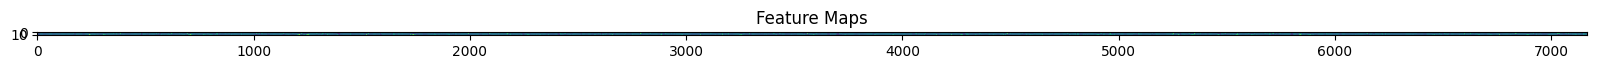

In [ ]:
plt.figure(figsize=(scale*n_features,scale))
plt.title("Feature Maps")
plt.grid(False)
plt.imshow(display_grid,aspect="auto")

Feature map shape: (1, 14, 14, 512)


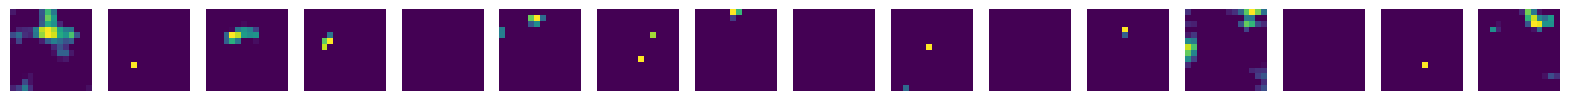

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model

# Visualize the feature maps
def plot_feature_maps(feature_maps, num_channels=16):
    """Plot the first num_channels feature maps."""
    channels = feature_maps.shape[-1]  # Total channels
    num_channels = min(num_channels, channels)
    fig, axes = plt.subplots(1, num_channels, figsize=(20, 20))
    for i in range(num_channels):
        ax = axes[i]
        ax.imshow(feature_maps[0, :, :, i], cmap='viridis')
        ax.axis('off')
    plt.show()

# Display feature maps
print("Feature map shape:", feature_maps.shape)  # Shape: (1, height, width, channels)
plot_feature_maps(feature_maps, num_channels=16)  # Adjust channels as needed


# Featuremap extracting using VGG19

In [ ]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input

In [ ]:
base_model = VGG19(weights='imagenet')

574710816/574710816 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


In [ ]:
layer_name = 'block5_conv4'
model = Model(inputs=base_model.input, outputs=base_model.get_layer(layer_name).output)


In [ ]:
img = load_img(image_path, target_size=(224, 224))  # Resize to 224x224
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array = preprocess_input(img_array)  # Preprocess for VGG19


In [ ]:
feature_maps = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 854ms/step


In [ ]:
def plot_feature_maps(feature_maps, num_channels=16):
    """Plot the first num_channels feature maps."""
    channels = feature_maps.shape[-1]  # Total channels
    num_channels = min(num_channels, channels)
    fig, axes = plt.subplots(1, num_channels, figsize=(20, 20))
    for i in range(num_channels):
        ax = axes[i]
        ax.imshow(feature_maps[0, :, :, i], cmap='viridis')
        ax.axis('off')
    plt.show()


Feature map shape: (1, 14, 14, 512)


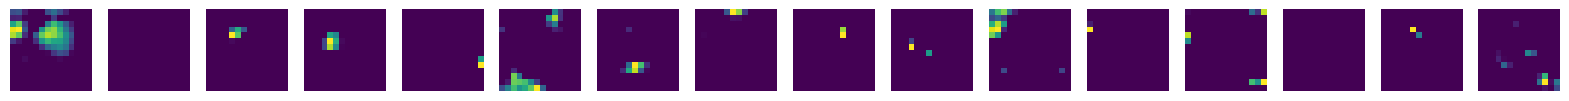

In [ ]:
print("Feature map shape:", feature_maps.shape)  # Shape: (1, height, width, channels)
plot_feature_maps(feature_maps, num_channels=16)  # Adjust channels as needed

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model

In [ ]:
import tensorflow as tf
import numpy as np


In [ ]:
base_model=tf.keras.applications.ResNet50(weights="imagenet",include_top=False)
base_model.trainable=False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
img=tf.keras.preprocessing.image.load_img("/content/drive/MyDrive/ROCO_dataset/data/test/non-radiology/images/ROCO_81827.jpg",target_size=(224,224))

In [ ]:
img_array=tf.keras.preprocessing.image.img_to_array(img)
img_array=np.expand_dims(img_array,axis=0)

In [ ]:
img_array.shape

(1, 224, 224, 3)

In [ ]:
img_array=tf.keras.applications.resnet.preprocess_input(img_array)

In [ ]:
img_array.shape

(1, 224, 224, 3)

In [ ]:
img_array

array([[[[ 9.0609970e+00, -6.7789993e+00, -1.7680000e+01],
         [ 6.0997009e-02, -1.5778999e+01, -2.6680000e+01],
         [ 1.0060997e+01, -5.7789993e+00, -1.6680000e+01],
         ...,
         [ 9.7060997e+01,  8.1221001e+01,  7.0320000e+01],
         [ 1.0606100e+02,  9.0221001e+01,  7.9320000e+01],
         [ 1.0106100e+02,  8.5221001e+01,  7.4320000e+01]],

        [[ 4.0609970e+00, -1.1778999e+01, -2.2680000e+01],
         [ 6.0609970e+00, -9.7789993e+00, -2.0680000e+01],
         [ 1.4060997e+01, -1.7789993e+00, -1.2680000e+01],
         ...,
         [ 9.6060997e+01,  8.0221001e+01,  6.9320000e+01],
         [ 1.0206100e+02,  8.6221001e+01,  7.5320000e+01],
         [ 1.0206100e+02,  8.6221001e+01,  7.5320000e+01]],

        [[ 7.0609970e+00, -8.7789993e+00, -1.9680000e+01],
         [ 9.0609970e+00, -6.7789993e+00, -1.7680000e+01],
         [ 1.1060997e+01, -4.7789993e+00, -1.5680000e+01],
         ...,
         [ 9.5060997e+01,  7.9221001e+01,  6.8320000e+01],
         [

In [ ]:
feature_map=base_model(img_array)

In [ ]:
feature_map.shape

TensorShape([1, 7, 7, 2048])

Feature map shape: (1, 14, 14, 512)


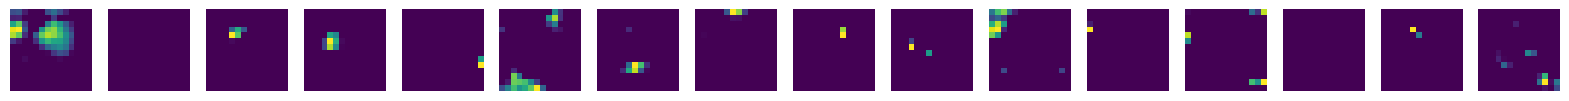

In [ ]:
def plot_feature_maps(feature_maps, num_channels=16):
    """Plot the first num_channels feature maps."""
    channels = feature_maps.shape[-1]  # Total channels
    num_channels = min(num_channels, channels)
    fig, axes = plt.subplots(1, num_channels, figsize=(20, 20))
    for i in range(num_channels):
        ax = axes[i]
        ax.imshow(feature_maps[0, :, :, i], cmap='viridis')
        ax.axis('off')
    plt.show()

# Display feature maps
print("Feature map shape:", feature_maps.shape)  # Shape: (1, height, width, channels)
plot_feature_maps(feature_maps, num_channels=16)

# ANN

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
radiology_caption=pd.read_table("/content/drive/MyDrive/ROCO_dataset/data/test/radiology/captions.txt",names=['image_id','caption'])

In [ ]:
radiology_caption

,image_id,caption
0,ROCO_00001,Axial MRI (coronal view).
1,ROCO_00006,Coronal plain computed tomography image showi...
2,ROCO_00016,Axial source image from an intracranial magne...
3,ROCO_00025,"The apical height, homogeneity, and the thick..."
4,ROCO_00031,CTO of RCA (closure in the 2nd segment)
...,...,...
8174,ROCO_81771,Damus–Kaye–Stansel shunt. Oblique coronal MIP...
8175,ROCO_81778,"MRI pelvis post-radiation, axial STIR/T2W FSE..."
8176,ROCO_81792,Fluoroscopic image showing attempts to grab t...
8177,ROCO_81796,Positron emission tomography–computed tomogra...


In [ ]:
for i in range(len(radiology_caption['caption'])):
  radiology_caption['caption_len']=len(radiology_caption['caption'][i])

In [ ]:
radiology_caption

,image_id,caption,caption_len
0,ROCO_00002,Computed tomography scan in axial view showin...,738
1,ROCO_00003,Bacterial contamination occurred after comple...,738
2,ROCO_00004,The patient had residual paralysis of the han...,738
3,ROCO_00005,Panoramic radiograph after immediate loading.,738
4,ROCO_00007,Plain abdomen x-ray: Multiple air levels at t...,738
...,...,...,...
65445,ROCO_81819,Initial CT abdomen with contrast showing a di...,738
65446,ROCO_81820,44-year-old male patient after surgical amput...,738
65447,ROCO_81821,Primary pulmonary tuberculosis in 18-year-old...,738
65448,ROCO_81822,"MRI brain with gadolinium, coronal view, show...",738


In [ ]:
tfidf=TfidfVectorizer(max_features=50)

In [ ]:
X=tfidf.fit_transform(radiology_caption['caption']).toarray()
y=radiology_caption['caption_len']

In [ ]:
X

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.45517327, 0.        , 0.        , ..., 0.        , 0.25205956,
        0.        ],
       [0.        , 0.        , 0.30264573, ..., 0.        , 0.1915367 ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.23093157,
        0.        ],
       [0.        , 0.        , 0.23610724, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

In [ ]:
model=Sequential([
                Dense(64,activation="relu",input_shape=(X.shape[1],)),
                Dropout(0.5),
                Dense(32,activation="relu"),
                Dense(1,activation="sigmoid")

])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001),loss=BinaryCrossentropy(),metrics=['accuracy'])

In [ ]:
model.fit(X,y,epochs=10)

Epoch 1/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.0000e+00 - loss: -1951.4359
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0000e+00 - loss: -85146.2812
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0000e+00 - loss: -501335.1875
Epoch 4/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0000e+00 - loss: -1480819.7500
Epoch 5/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0000e+00 - loss: -3178132.0000
Epoch 6/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0000e+00 - loss: -5754821.0000
Epoch 7/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0000e+00 - loss: -9215516.0000
Epoch 8/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0000e+00 - loss: -13815694.0000
Epoch 9/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0000e+00 - loss: -19348194.0000
Epoch 10/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0000e+00 - loss: -26176900.0000


In [ ]:
loss,accuracy=model.evaluate(X,y)

256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0000e+00 - loss: -32054500.0000


In [ ]:
loss,accuracy

(-32018478.0, 0.0)

In [ ]:
model.predict(X)

256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


array([[1.],
       [1.],
       [1.],
       ...,
       [1.],
       [1.],
       [1.]], dtype=float32)

In [ ]:
y

,caption_len
0,96
1,96
2,96
3,96
4,96
...,...
8174,96
8175,96
8176,96
8177,96


In [ ]:
data={
    "Title": [
        "Breaking news: COVID-19 vaccine is a scam!",
        "NASA discovers new planet with signs of life",
        "Fake celebrity dies in car crash story circulates",
        "New study confirms coffee boosts productivity"
    ],
    "Label": [1, 0, 1, 0]  # 1 = Fake, 0 = Real
}

In [ ]:
df=pd.DataFrame(data)

In [ ]:
tfidf=TfidfVectorizer(max_features=50)

In [ ]:
X=tfidf.fit_transform(df['Title']).toarray()
y=df['Label']

In [ ]:
# X=tfidf.fit_transform(df['image_id']).toarray()
# y=df['caption']

In [ ]:
X

array([[0.37796447, 0.        , 0.37796447, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.37796447, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.37796447,
        0.        , 0.        , 0.        , 0.37796447, 0.        ,
        0.        , 0.        , 0.37796447, 0.        , 0.        ,
        0.        , 0.37796447, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.36222393, 0.        , 0.        , 0.        ,
        0.36222393, 0.36222393, 0.2855815 , 0.        , 0.36222393,
        0.36222393, 0.        , 0.        , 0.36222393, 0.        ,
        0.        , 0.        , 0.36222393],
       [0.        , 0.        , 0.        , 0.35355339, 0.35355339,
        0.35355339, 0.        , 0.        , 0.        , 0.35355339,
        0.35355339, 0.        , 0.35355339, 0.35355339, 0.        ,
        0.        , 0.    

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

In [ ]:
model=Sequential([
                Dense(64,activation="relu",input_shape=(X.shape[1],)),
                Dropout(0.5),
                Dense(32,activation="relu"),
                Dense(1,activation="sigmoid")

])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001),loss=BinaryCrossentropy(),metrics=['accuracy'])

In [ ]:
model.fit(X,y,epochs=10)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7500 - loss: 0.6896
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.5000 - loss: 0.7071
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2500 - loss: 0.7308
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7500 - loss: 0.6665
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7500 - loss: 0.6423
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - loss: 0.6656
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2500 - loss: 0.6995
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7500 - loss: 0.6941
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7500 - loss: 0.6932
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5000 - loss: 0.6623


In [ ]:
loss,accuracy=model.evaluate(X,y)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.7500 - loss: 0.6597


In [ ]:
loss,accuracy

(0.6596916913986206, 0.75)

In [ ]:
model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


array([[0.5331152 ],
       [0.4628893 ],
       [0.50815815],
       [0.50896263]], dtype=float32)

In [ ]:
y

,Label
0,1
1,0
2,1
3,0


# **RNN**

In [ ]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 19.4 MB/s eta 0:00:00


In [ ]:
from faker import Faker

In [ ]:
fake=Faker()
Faker.seed(42)

In [ ]:
def generate_text_labels(num_samples=5000):
  text=[fake.sentence(nb_words=10) for i in range(num_samples)]
  labels=np.random.randint(0,2,num_samples)
  return text,labels

In [ ]:
text,labels=generate_text_labels()

In [ ]:
text

['Agent every development say quality throughout beautiful.',
 'All behavior discussion own night respond red information last everything thank.',
 'Recently future choice whatever from behavior benefit suggest.',
 'Enough analysis least by two bad fall pick those gun court attorney product.',
 'World talk term herself law street class great prove.',
 'Participant commercial rock clear here writer.',
 'Detail food shoulder argue start source husband at tree note responsibility defense material.',
 'Central cause seat much section investment on gun young catch management.',
 'Technology check civil quite others his.',
 'You more wife team activity result race Mr environment political born itself law.',
 'Will seven medical blood personal success medical current hear.',
 'Much single morning a food affect upon these.',
 'Dream drive note bad rule staff within mouth call.',
 'Water close month parent who up sense ready require human public health.',
 'Later easy ask again network open acc

In [ ]:
labels

array([1, 0, 1, ..., 0, 1, 0])

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [ ]:
tokenizer=Tokenizer(num_words=5000)

In [ ]:
tokenizer.fit_on_texts(text)

In [ ]:
sequences=tokenizer.texts_to_sequences(text)

In [ ]:
sequences

[[738, 228, 739, 821, 378, 191, 650],
 [330, 29, 379, 487, 192, 782, 229, 740, 282, 42, 822],
 [230, 30, 331, 117, 741, 29, 231, 22],
 [651, 91, 283, 590, 284, 118, 285, 652, 119, 120, 783, 784, 332],
 [424, 193, 23, 425, 16, 43, 785, 426, 742],
 [333, 956, 286, 121, 334, 743],
 [957, 696, 92, 335, 653, 75, 122, 427, 428, 76, 591, 232, 194],
 [592, 233, 915, 697, 336, 593, 698, 120, 429, 123, 699],
 [744, 870, 700, 195, 337, 338],
 [5, 60, 44, 594, 339, 234, 488, 287, 288, 31, 654, 289, 16],
 [538, 430, 340, 61, 290, 235, 340, 952, 786],
 [697, 45, 964, 431, 696, 871, 936, 432],
 [380, 291, 76, 118, 823, 787, 152, 539, 341],
 [46, 655, 489, 32, 656, 196, 24, 197, 342, 788, 153, 236],
 [490, 491, 492, 62, 595, 824, 343, 745, 237, 2, 330, 596],
 [540, 292, 238, 433, 825, 124, 344, 541, 542, 77, 434, 381],
 [154, 78, 8, 701, 493, 382, 286, 345, 597, 783, 890],
 [33, 42, 63, 746, 383, 744, 93],
 [543, 155, 916, 29, 747, 702],
 [494, 657, 122, 198, 598, 424, 435, 541, 293, 294, 117],
 [332,

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded_sequences=pad_sequences(sequences,maxlen=20)

In [ ]:
padded_sequences[:2]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        738, 228, 739, 821, 378, 191, 650],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 330,  29, 379, 487,
        192, 782, 229, 740, 282,  42, 822]], dtype=int32)

In [ ]:
train_size=int(0.8*len(padded_sequences))

In [ ]:
train_size

4000

In [ ]:
X_train,X_test=padded_sequences[:train_size],padded_sequences[train_size:]
y_train,y_test=labels[:train_size],labels[train_size:]

In [ ]:
X_train

array([[  0,   0,   0, ..., 378, 191, 650],
       [  0,   0,   0, ..., 282,  42, 822],
       [  0,   0,   0, ...,  29, 231,  22],
       ...,
       [  0,   0,   0, ..., 220, 935, 730],
       [  0,   0,   0, ..., 734, 649, 361],
       [  0,   0,   0, ...,   6,  63, 515]], dtype=int32)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense

In [ ]:
model=Sequential([Embedding(input_dim=5000,output_dim=64,input_length=20),
                  SimpleRNN(64,return_sequences=False),
                  Dense(1,activation="sigmoid")
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=['accuracy'])

In [ ]:
model.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5017 - loss: 0.6972 - val_accuracy: 0.5150 - val_loss: 0.6931
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7926 - loss: 0.5841 - val_accuracy: 0.4825 - val_loss: 0.8097
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9153 - loss: 0.2645 - val_accuracy: 0.4837 - val_loss: 1.1806
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9836 - loss: 0.0873 - val_accuracy: 0.4837 - val_loss: 1.8163
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9962 - loss: 0.0249 - val_accuracy: 0.4888 - val_loss: 2.1805
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9987 - loss: 0.0105 - val_accuracy: 0.4875 - val_loss: 2.3226
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9997 - loss: 0.0039 - val_accuracy: 0.4925 - val_loss: 2.5333
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accu

In [ ]:
model.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


array([[4.99222800e-03],
       [7.01474786e-01],
       [1.56684164e-02],
       [8.27368677e-01],
       [1.51683751e-04],
       [9.99955952e-01],
       [2.54056249e-06],
       [1.43158052e-03],
       [9.99749482e-01],
       [9.99556899e-01],
       [3.72122899e-02],
       [9.99591827e-01],
       [9.99928772e-01],
       [6.03806460e-03],
       [8.95344769e-04],
       [9.99901175e-01],
       [9.74637747e-01],
       [9.95825291e-01],
       [9.69177485e-01],
       [9.98509288e-01],
       [1.17423211e-03],
       [5.50517261e-01],
       [2.97145266e-03],
       [9.82733190e-01],
       [4.51396018e-01],
       [9.99415636e-01],
       [2.03167461e-03],
       [9.16074336e-01],
       [7.72070706e-01],
       [9.98369455e-01],
       [9.80695844e-01],
       [9.67467844e-01],
       [9.68784153e-01],
       [8.59414399e-01],
       [7.53378146e-04],
       [8.90740275e-01],
       [8.71567667e-01],
       [1.28395453e-01],
       [6.83744019e-03],
       [6.90515578e-01],


In [3]:
import pandas as pd
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [5]:
image_folder = '/content/drive/MyDrive/ROCO_dataset/data/train/non-radiology/images'

images = []
labels = []

image_files = os.listdir(image_folder)

for filename in image_files:

    img_path = os.path.join(image_folder, filename)
    img = load_img(img_path, target_size=(150, 150))


    img_array = img_to_array(img) / 255.0


    images.append(img_array)

    label = filename.split('_')[0]
    labels.append(label)

# Convert the lists to NumPy arrays
images = np.array(images)
labels = np.array(labels)

# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Fit the encoder to your labels
label_encoder.fit(labels)

# Transform your labels into numerical representations
labels = label_encoder.transform(labels)

# Now you can use these encoded labels for training your model
X_train, X_temp, y_train, y_temp = train_test_split(images, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_val, y_val)
)


Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.9543 - loss: 0.0384 - val_accuracy: 1.0000 - val_loss: 1.8654e-32
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 1.0000 - loss: 1.2825e-27 - val_accuracy: 1.0000 - val_loss: 1.8608e-32
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 1.0000 - loss: 1.2825e-27 - val_accuracy: 1.0000 - val_loss: 1.8608e-32
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 1.0000 - loss: 1.7082e-27 - val_accuracy: 1.0000 - val_loss: 1.8608e-32
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 1.0000 - loss: 5.4272e-29 - val_accuracy: 1.0000 - val_loss: 1.8608e-32
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 1.0000 - loss: 9.2435e-28 - val_accuracy: 1.0000 - val_loss: 1.8608e-32
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 1.0000 - loss: 2.1618e-27 - val_accuracy: 1.0000 - val_loss: 1.8608e-32
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 202s 

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc}")


23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 356ms/step - accuracy: 1.0000 - loss: 3.8051e-29
Test Accuracy: 1.0


# Trained images using Rnn

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Flatten, LSTM, Reshape

In [8]:
model = Sequential()

model.add(Flatten(input_shape=(150, 150, 3)))
model.add(Reshape((150, 450)))

model.add(SimpleRNN(128, activation='relu'))

model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_val, y_val)
)


Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 160ms/step - accuracy: 0.9476 - loss: 0.1235 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 14s 131ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 22s 137ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 20s 133ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 122ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
107/107 ━━━━━━━━━━━━

In [11]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc}")


23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Test Accuracy: 1.0


In [12]:
model.save('rnn_image_model.h5')


Trained images using ANN

In [17]:
1from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Build the ANN model
model = Sequential()
model.add(Flatten(input_shape=(150, 150, 3)))  # Flatten the input image

# Input layer
model.add(Dense(128, activation='relu'))  # Input size is automatically inferred

# Hidden layers
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

# Output layer
model.add(Dense(1, activation='sigmoid'))  # Binary classification, outputting a single value

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_val, y_val)
)

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 22s 207ms/step - accuracy: 1.0000 - loss: 1.2777e-15 - val_accuracy: 1.0000 - val_loss: 2.5479e-20
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 36s 162ms/step - accuracy: 1.0000 - loss: 1.8547e-15 - val_accuracy: 1.0000 - val_loss: 2.5479e-20
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 20s 155ms/step - accuracy: 1.0000 - loss: 1.4656e-15 - val_accuracy: 1.0000 - val_loss: 2.5479e-20
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 21s 162ms/step - accuracy: 1.0000 - loss: 3.4230e-15 - val_accuracy: 1.0000 - val_loss: 2.5479e-20
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 17s 157ms/step - accuracy: 1.0000 - loss: 1.8200e-15 - val_accuracy: 1.0000 - val_loss: 2.5479e-20
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 17s 162ms/step - accuracy: 1.0000 - loss: 4.2896e-15 - val_accuracy: 1.0000 - val_loss: 2.5479e-20
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 146ms/step - accuracy: 1.0000 - loss: 1.8801e-15 - val_accuracy: 1.0000 - val_loss: 2.5479e-20
Epoch 8/10
107/107 ━━━━━━━━

In [21]:
X_train

array([[[[0.69411767, 0.67058825, 0.62352943],
         [0.75686276, 0.72156864, 0.69411767],
         [0.7176471 , 0.6901961 , 0.65882355],
         ...,
         [0.77254903, 0.7372549 , 0.70980394],
         [0.7490196 , 0.7137255 , 0.6862745 ],
         [0.78431374, 0.75686276, 0.7176471 ]],

        [[0.6862745 , 0.65882355, 0.61960787],
         [0.7372549 , 0.7019608 , 0.6666667 ],
         [0.7058824 , 0.67058825, 0.63529414],
         ...,
         [0.7882353 , 0.7529412 , 0.7176471 ],
         [0.7882353 , 0.7529412 , 0.7176471 ],
         [0.7921569 , 0.75686276, 0.72156864]],

        [[0.72156864, 0.6862745 , 0.6509804 ],
         [0.74509805, 0.70980394, 0.6901961 ],
         [0.7411765 , 0.7058824 , 0.67058825],
         ...,
         [0.8039216 , 0.7764706 , 0.74509805],
         [0.77254903, 0.7372549 , 0.70980394],
         [0.76862746, 0.73333335, 0.69803923]],

        ...,

        [[0.8784314 , 0.85490197, 0.85490197],
         [0.91764706, 0.8784314 , 0.88235295]

In [22]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc}")


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 3.5867e-10
Test Accuracy: 1.0


# LSTM

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense

# Build a CNN-LSTM model
model = Sequential()

# CNN layers for feature extraction
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())

# LSTM layer
model.add(Reshape((-1, 128)))  # Reshape for LSTM input
model.add(LSTM(128, activation='tanh'))

# Fully connected output layer
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_val, y_val)
)


Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - accuracy: 0.9528 - loss: 0.0937 - val_accuracy: 1.0000 - val_loss: 8.7917e-07
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 1.0000 - loss: 8.5475e-07 - val_accuracy: 1.0000 - val_loss: 7.8182e-07
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 258s 2s/step - accuracy: 1.0000 - loss: 7.6307e-07 - val_accuracy: 1.0000 - val_loss: 6.8749e-07
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 1.0000 - loss: 6.5954e-07 - val_accuracy: 1.0000 - val_loss: 6.0833e-07
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - accuracy: 1.0000 - loss: 6.0060e-07 - val_accuracy: 1.0000 - val_loss: 5.4252e-07
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 1.0000 - loss: 5.2492e-07 - val_accuracy: 1.0000 - val_loss: 4.8549e-07
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 1.0000 - loss: 4.7167e-07 - val_accuracy: 1.0000 - val_loss: 4.3614e-07
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 269s 

In [28]:
X_train

array([[[[0.69411767, 0.67058825, 0.62352943],
         [0.75686276, 0.72156864, 0.69411767],
         [0.7176471 , 0.6901961 , 0.65882355],
         ...,
         [0.77254903, 0.7372549 , 0.70980394],
         [0.7490196 , 0.7137255 , 0.6862745 ],
         [0.78431374, 0.75686276, 0.7176471 ]],

        [[0.6862745 , 0.65882355, 0.61960787],
         [0.7372549 , 0.7019608 , 0.6666667 ],
         [0.7058824 , 0.67058825, 0.63529414],
         ...,
         [0.7882353 , 0.7529412 , 0.7176471 ],
         [0.7882353 , 0.7529412 , 0.7176471 ],
         [0.7921569 , 0.75686276, 0.72156864]],

        [[0.72156864, 0.6862745 , 0.6509804 ],
         [0.74509805, 0.70980394, 0.6901961 ],
         [0.7411765 , 0.7058824 , 0.67058825],
         ...,
         [0.8039216 , 0.7764706 , 0.74509805],
         [0.77254903, 0.7372549 , 0.70980394],
         [0.76862746, 0.73333335, 0.69803923]],

        ...,

        [[0.8784314 , 0.85490197, 0.85490197],
         [0.91764706, 0.8784314 , 0.88235295]

In [27]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 597ms/step - accuracy: 1.0000 - loss: 3.0822e-07
Test Accuracy: 1.0


In [30]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 21.7 MB/s eta 0:00:00


In [31]:
from faker import Faker
import random

In [32]:
caption=pd.read_table("/content/drive/MyDrive/ROCO_dataset/data/test/radiology/captions.txt",names=['image_id','caption'])
caption

,image_id,caption
0,ROCO_00001,Axial MRI (coronal view).
1,ROCO_00006,Coronal plain computed tomography image showi...
2,ROCO_00016,Axial source image from an intracranial magne...
3,ROCO_00025,"The apical height, homogeneity, and the thick..."
4,ROCO_00031,CTO of RCA (closure in the 2nd segment)
...,...,...
8174,ROCO_81771,Damus–Kaye–Stansel shunt. Oblique coronal MIP...
8175,ROCO_81778,"MRI pelvis post-radiation, axial STIR/T2W FSE..."
8176,ROCO_81792,Fluoroscopic image showing attempts to grab t...
8177,ROCO_81796,Positron emission tomography–computed tomogra...


In [34]:
texts=[]
labels=[]
for i in caption['caption']:
  if random.random()>0.5:
    texts.append(i)
    labels.append(1)
  else:
    texts.append(i)
    labels.append(0)

In [35]:
labels

[0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,


In [36]:
train_texts=texts[:1600]
test_texts=texts[1600:]
train_labels=labels[:1600]
test_labels=labels[1600:]

In [37]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [38]:
tokenizer=Tokenizer()
tokenizer.fit_on_texts(train_texts)

In [39]:
train_sequences=tokenizer.texts_to_sequences(train_texts)
test_sequences=tokenizer.texts_to_sequences(test_texts)

In [40]:
word_index=tokenizer.word_index

In [41]:
max_sequence_length=max(len(seq) for seq in train_sequences)

In [42]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [43]:
max_sequence_length

162

In [44]:
train_padded=pad_sequences(train_sequences,maxlen=max_sequence_length,padding="post")
test_padded=pad_sequences(test_sequences,maxlen=max_sequence_length,padding="post")



In [45]:
test_padded

array([[  32,  104,  779, ...,    0,    0,    0],
       [  22,   17,    7, ...,    0,    0,    0],
       [ 499,  214,  925, ...,    0,    0,    0],
       ...,
       [ 357,   13,    7, ...,    0,    0,    0],
       [ 728,  637,   17, ...,    0,    0,    0],
       [1765,    7,    1, ...,    0,    0,    0]], dtype=int32)

In [46]:
from tensorflow.keras.utils import to_categorical

In [47]:
train_labels=to_categorical(train_labels)
test_labels=to_categorical(test_labels)

In [48]:
train_labels

array([[1., 0.],
       [0., 1.],
       [0., 1.],
       ...,
       [0., 1.],
       [0., 1.],
       [1., 0.]])

In [49]:
from gensim.models import Word2Vec

In [50]:
w2v_model=Word2Vec(sentences=[text.split() for text in train_texts],vector_size=100)

In [51]:
embedding_dim=100
embedding_matrix=np.zeros((len(word_index)+1,embedding_dim))

In [52]:
for word,i in word_index.items():
  if word in w2v_model.wv:
    embedding_matrix[i]=w2v_model.wv[word]


In [53]:
embedding_matrix


array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.56373298,  0.33037528,  0.16388822, ..., -0.66813141,
         0.13412555, -0.28841045],
       [-0.58689731,  0.3448647 ,  0.16110918, ..., -0.67350227,
         0.1238781 , -0.2888324 ],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense

In [55]:
model=Sequential([
        Embedding(input_dim=len(word_index)+1,
                  output_dim=embedding_dim,
                  weights=[embedding_matrix],
        input_length=max_sequence_length,
        trainable=False),
        LSTM(128),
        Dense(2,activation="softmax")
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [56]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [57]:
model.fit(train_padded,train_labels,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 279ms/step - accuracy: 0.4546 - loss: 0.6938 - val_accuracy: 0.5375 - val_loss: 0.6926
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 244ms/step - accuracy: 0.4854 - loss: 0.6933 - val_accuracy: 0.5375 - val_loss: 0.6915
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 236ms/step - accuracy: 0.4813 - loss: 0.6943 - val_accuracy: 0.5375 - val_loss: 0.6911
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 285ms/step - accuracy: 0.5196 - loss: 0.6921 - val_accuracy: 0.5375 - val_loss: 0.6919
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 213ms/step - accuracy: 0.4735 - loss: 0.7680 - val_accuracy: 0.5375 - val_loss: 0.6925
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 269ms/step - accuracy: 0.5038 - loss: 0.6970 - val_accuracy: 0.4625 - val_loss: 0.6932
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 249ms/step - accuracy: 0.4759 - loss: 0.6937 - val_accuracy: 0.4625 - val_loss: 0.6932
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 238ms/step - accuracy: 0.5099 - loss: 0.6949 - val_accu

In [58]:
test_loss,test_accuracy=model.evaluate(test_padded,test_labels)
test_accuracy

206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - accuracy: 0.4990 - loss: 0.6935


0.4990119934082031

# Bidirectional

In [59]:
from tensorflow.keras.layers import Bidirectional

In [60]:
model=Sequential([
        Embedding(input_dim=len(word_index)+1,
                  output_dim=embedding_dim,
                  weights=[embedding_matrix],
        input_length=max_sequence_length,
        trainable=False),
        Bidirectional(LSTM(128)),
        Dense(2,activation="softmax")
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [61]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [62]:
model.fit(train_padded,train_labels,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 517ms/step - accuracy: 0.4742 - loss: 0.7114 - val_accuracy: 0.5375 - val_loss: 0.6918
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 40s 512ms/step - accuracy: 0.5167 - loss: 0.6934 - val_accuracy: 0.4656 - val_loss: 0.6938
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 491ms/step - accuracy: 0.5045 - loss: 0.6929 - val_accuracy: 0.5281 - val_loss: 0.6912
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 476ms/step - accuracy: 0.4679 - loss: 0.7010 - val_accuracy: 0.5125 - val_loss: 0.6933
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 475ms/step - accuracy: 0.4767 - loss: 0.6943 - val_accuracy: 0.5437 - val_loss: 0.6913
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 23s 521ms/step - accuracy: 0.5145 - loss: 0.6911 - val_accuracy: 0.5312 - val_loss: 0.6920
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 39s 486ms/step - accuracy: 0.5210 - loss: 0.6914 - val_accuracy: 0.5250 - val_loss: 0.6920
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 490ms/step - accuracy: 0.5244 - loss: 0.6917 - val_accu

In [63]:
test_loss,test_accuracy=model.evaluate(test_padded,test_labels)
test_accuracy

206/206 ━━━━━━━━━━━━━━━━━━━━ 34s 161ms/step - accuracy: 0.5032 - loss: 0.6934


0.5015959739685059

# Stacked LSTM

In [67]:
model=Sequential([
    Embedding(input_dim=len(word_index)+1,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              input_length=max_sequence_length,
              trainable=False),
    LSTM(128, return_sequences=True),  # Added return_sequences=True
    LSTM(64),
    Dense(2,activation="softmax")
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [68]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [69]:
model.fit(train_padded,train_labels,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 389ms/step - accuracy: 0.5316 - loss: 0.6933 - val_accuracy: 0.4625 - val_loss: 0.6945
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 361ms/step - accuracy: 0.5033 - loss: 0.6932 - val_accuracy: 0.5375 - val_loss: 0.6918
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 381ms/step - accuracy: 0.5057 - loss: 0.6920 - val_accuracy: 0.5375 - val_loss: 0.6917
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 389ms/step - accuracy: 0.5079 - loss: 0.6928 - val_accuracy: 0.5375 - val_loss: 0.6919
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 360ms/step - accuracy: 0.4947 - loss: 0.6933 - val_accuracy: 0.5375 - val_loss: 0.6916
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 385ms/step - accuracy: 0.5102 - loss: 0.6953 - val_accuracy: 0.5375 - val_loss: 0.6923
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 379ms/step - accuracy: 0.5206 - loss: 0.6928 - val_accuracy: 0.5375 - val_loss: 0.6921
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 382ms/step - accuracy: 0.4612 - loss: 0.6938 - val_accu

In [70]:
test_loss,test_accuracy=model.evaluate(test_padded,test_labels)
test_accuracy

206/206 ━━━━━━━━━━━━━━━━━━━━ 27s 129ms/step - accuracy: 0.4990 - loss: 0.6932


0.4990119934082031

# Dropout LSTM

In [71]:
model=Sequential([
        Embedding(input_dim=len(word_index)+1,
                  output_dim=embedding_dim,
                  weights=[embedding_matrix],
        input_length=max_sequence_length,
        trainable=False),
        LSTM(128,dropout=0.2,),
        Dense(2,activation="softmax")
])

In [72]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [73]:
model.fit(train_padded,train_labels,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 256ms/step - accuracy: 0.4875 - loss: 0.6937 - val_accuracy: 0.5375 - val_loss: 0.6920
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 256ms/step - accuracy: 0.5105 - loss: 0.6932 - val_accuracy: 0.5375 - val_loss: 0.6918
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 22s 292ms/step - accuracy: 0.5184 - loss: 0.6926 - val_accuracy: 0.5375 - val_loss: 0.6918
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 294ms/step - accuracy: 0.5143 - loss: 0.6924 - val_accuracy: 0.5375 - val_loss: 0.6925
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 231ms/step - accuracy: 0.4358 - loss: 0.6940 - val_accuracy: 0.5375 - val_loss: 0.6919
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 259ms/step - accuracy: 0.5182 - loss: 0.6939 - val_accuracy: 0.5375 - val_loss: 0.6921
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 22s 290ms/step - accuracy: 0.5195 - loss: 0.6918 - val_accuracy: 0.5375 - val_loss: 0.6923
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 225ms/step - accuracy: 0.5251 - loss: 0.6925 - val_accur

In [74]:
test_loss,test_accuracy=model.evaluate(test_padded,test_labels)
test_accuracy

206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - accuracy: 0.4994 - loss: 0.6934


0.4990119934082031